In [1]:
import torch 
from sim_loader.abacus_io import AbacusSummitSim
from sim_loader import setup_logging
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
    'load_field_particles': True  # Whether to load field particles
}
setup_logging()
test=AbacusSummitSim(**default_abacus_param)

[000000.00]  10-07 09:03 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.00]  10-07 09:03 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...


/home/antoine/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


[000003.83]  10-07 09:03 AbacusSummitSim              INFO     Done took 00:00:03
[000003.84]  10-07 09:03 AbacusSummitSim              INFO     Compute required columns...
[000004.44]  10-07 09:03 AbacusSummitSim              INFO     Done took 00:00:00
[000004.44]  10-07 09:03 AbacusSummitSim              INFO     Load Abacus particles using 10.000% of the subsample A...
[000005.70]  10-07 09:03 AbacusSummitSim              INFO     [0/2] halo_rv_A_000.asdf: 5,958,945 / 59,589,449 particles retained
[000008.28]  10-07 09:03 AbacusSummitSim              INFO     [1/2] field_rv_A_000.asdf: 9,520,723 / 95,207,226 particles retained
[000008.66]  10-07 09:03 AbacusSummitSim              INFO     Compiled 15479668 particles, took time: 4.2247395515441895


In [68]:
from HODDIES.sim_loader.abacus_io import AbacusSummitSim

NTHREADS = 8
FIX_SEED = 42
N_VARIATIONS = 20  # np.linspace default: lower this for a quicker preview

default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
    'load_field_particles': True  # Whether to load field particles
    
}

test=AbacusSummitSim(**default_abacus_param, nthreads=NTHREADS)

[001906.16]  10-07 09:35 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[001906.16]  10-07 09:35 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...
[001909.47]  10-07 09:35 AbacusSummitSim              INFO     Done took 00:00:03
[001909.47]  10-07 09:35 AbacusSummitSim              INFO     Compute required columns...
[001909.54]  10-07 09:35 AbacusSummitSim              INFO     Done took 00:00:00
[001909.54]  10-07 09:35 AbacusSummitSim              INFO     Load Abacus particles using 10.000% of the subsample A...
[001910.94]  10-07 09:35 AbacusSummitSim              INFO     [0/2] halo_rv_A_000.asdf: 5,958,945 / 59,589,449 particles retained
[001913.47]  10-07 09:35 AbacusSummitSim              INFO     [1/2] field_rv_A_000.asdf: 9,520,723 / 95,207,226 particles retained
[001913.87]  10-07 09:35 AbacusSummitSim              INFO

In [ ]:
from HODDIES.plot_utils import get_STATS, register_stat
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from HODDIES import HOD 
import torch 
from sim_loader.abacus_io import AbacusSummitSim
from sim_loader import setup_logging
setup_logging()

NTHREADS = 8
FIX_SEED = 42
N_VARIATIONS = 20  # np.linspace default: lower this for a quicker preview

default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
    'load_field_particles': True  # Whether to load field particles
    
}

test=AbacusSummitSim(**default_abacus_param, nthreads=NTHREADS)


PARAMETER_GRIDS = {
    "f_sigv": np.linspace(0.5, 1.5, N_VARIATIONS),
    "f_vcen": np.linspace(0.0, 0.5, N_VARIATIONS),
    "assembly_bias": np.linspace(-1.0, 1.0, N_VARIATIONS),
    "nu": np.linspace(0.7, 2.0, N_VARIATIONS),
}
LRG_FIDUCIAL = dict(
    HOD_model="SHOD", Ac=0.6, log_Mcent=12.8, sigma_M=0.4,
    satellites=True, sat_HOD_model="Nsat_pow_law",
    As=0.6, M_0=12.8, M_1=13.8, alpha=1.0,
    density=None, nu=1.0, link_sat_to_central=False, conformity_bias=False,
    vel_sat="rd_normal", f_sigv=1.0, f_vcen=0.0, vsmear=0.0,
    assembly_bias={"c": [0.0, 0.0], "shear": [0.0, 0.0], "env": [0.0, 0.0]},
)
HOD_model = HOD(base_catalog=test, use_assembly_bias=True, LRG=LRG_FIDUCIAL)

LRG_FIDUCIAL = deepcopy(HOD_model.args["LRG"])

cat_fid = HOD_model.make_mock_cat(fix_seed=FIX_SEED, verbose=True) 
rp, ds_data = HOD_model.get_wp(cat_fid)
s, (xi0_fid, xi2_fid) = HOD_model.get_xiells(cat_fid)

data = {'wp': (rp, ds_data)}

PLOT_STATS = []
for name in ("wp", "xi0", "xi2"):
    alias = f"{name}_fiducial_ratio"
    register_stat(alias, **{**vars(get_STATS()[name]), "residual": "ratio", "residual_ylim": None})
    PLOT_STATS.append(alias)
FIDUCIAL_DATA = {
    PLOT_STATS[0]: {"LRG": (rp, ds_data)},
    PLOT_STATS[1]: {"LRG": (s, xi0_fid)},
    PLOT_STATS[2]: {"LRG": (s, xi2_fid)},
}
run_summary = [{"parameter": "fiducial", "value": "—", "N": len(cat_fid),
                "f_sat": float(np.mean(cat_fid["Central"] == 0))}]


setup_logger True
[001442.92]  10-07 09:27 HOD                          INFO     Initializing HOD.
[001442.93]  10-07 09:27 HOD                          INFO     Set number of threads to 19
[001442.93]  10-07 09:27 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology
Assembly bias columns to remove: ['shear', 'c', 'env']
[001442.94]  10-07 09:27 HOD                          INFO     Create mock catalog for ['LRG']
Assembly bias columns to remove: ['shear', 'c', 'env']
[001442.94]  10-07 09:27 HOD                          INFO     Run HOD for LRG
[001443.05]  10-07 09:27 HOD                          WARNING  Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.
[001443.08]  10-07 09:27 HOD                          INFO     LRG mock catalogue done in 0.14 sec
[001443.09]  10-07 09:27 HOD                          INFO     Total time to create the mock catalog: 0.15 seconds
[0014

In [66]:

def scalar_parameters(params):
    flat = {key: value for key, value in params.items() if key != "assembly_bias"}
    for proxy, values in params["assembly_bias"].items():
        for index, value in enumerate(values):
            flat[f"assembly_bias.{proxy}.{index}"] = value
    return flat

def plot_variation(parameter, values, title, proxy=None, component=None):
    """Sweep one scalar; overlay wp, xi0 and xi2 with fiducial ratio residuals."""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) < 2 or not np.all(np.isfinite(values)) or np.ptp(values) == 0:
        raise ValueError("Provide a finite one-dimensional grid with at least two distinct values.")
    cmap = plt.get_cmap("viridis", len(values))
    norm = plt.Normalize(vmin=values.min(), vmax=values.max())
    fig = HOD_model.plot_stats(
        cat_fid, stats=PLOT_STATS, tracers=["LRG"], data=FIDUCIAL_DATA,
        residuals=True, show=False, color="black", data_color="0.35",
        label="Fiducial", figsize=(14, 6), fontsize=10, lw=2.2, zorder=4,
    )
    try:
        for value in values:
            color = cmap(norm(value))
            params = deepcopy(LRG_FIDUCIAL)
            key = parameter
            if proxy is None:
                params[parameter] = float(value)
            else:
                params["assembly_bias"][proxy][component] = float(value)
                key = f"assembly_bias.{proxy}.{component}"
            original, varied = scalar_parameters(LRG_FIDUCIAL), scalar_parameters(params)
            changed = [k for k in original if original[k] != varied[k]]
            # The grid may include the fiducial value, where no scalar changes.
            assert changed == ([key] if original[key] != varied[key] else []), (
                f"Expected only {key} to change; got {changed}"
            )
            HOD_model.args["LRG"] = params
            mock = HOD_model.make_mock_cat(fix_seed=FIX_SEED, verbose=False) if changed else cat_fid
            HOD_model.plot_stats(
                mock, stats=PLOT_STATS, tracers=["LRG"], fig=fig,
                residuals=True, show=False, color=color,
                label="_nolegend_", fontsize=10, lw=0.9, alpha=0.75,
            )
            run_summary.append({"parameter": key, "value": value, "N": len(mock),
                                "f_sat": float(np.mean(mock["Central"] == 0))})
            del mock
    finally:
        HOD_model.args["LRG"] = deepcopy(LRG_FIDUCIAL)
    # A colorbar replaces a long legend with one entry for every curve.
    # plot_stats uses a GridSpec with explicit bounds; move every panel
    # together to reserve space while keeping main/residual axes aligned.
    panels = [ax for main, resid in fig._plot_stats_axes
              for ax in (*main, *resid) if ax is not None]
    left = min(ax.get_position().x0 for ax in panels)
    right = max(ax.get_position().x1 for ax in panels)
    shrink = (0.86 - left) / (right - left)
    for ax in panels:
        pos = ax.get_position()
        ax.set_position([left + (pos.x0 - left) * shrink,
                         pos.y0, pos.width * shrink, pos.height])
    colorbar_axis = fig.add_axes([0.91, 0.16, 0.015, 0.68])
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(values)
    fig.colorbar(mappable, cax=colorbar_axis, label=parameter)
    fig.suptitle(title, y=1.02)
    plt.show()
    return fig

{'HOD_model': 'SHOD', 'Ac': 0.6, 'log_Mcent': 12.8, 'sigma_M': 0.4, 'gamma': 1, 'pmax': 1, 'Q': 100, 'satellites': True, 'sat_HOD_model': 'Nsat_pow_law', 'As': 0.6, 'M_0': 12.8, 'M_1': 13.8, 'alpha': 1.0, 'f_sigv': 1.0, 'f_vcen': 0.0, 'vel_sat': 'rd_normal', 'v_infall': 0, 'link_sat_to_central': False, 'assembly_bias': {'c': [0.0, 0.0], 'shear': [0.0, 0.0], 'env': [0.0, 0.0]}, 'nu': 1.0, 'conformity_bias': False, 'exp_frac': 0, 'exp_scale': 1, 'nfw_rescale': 1, 'density': None, 'vsmear': 0.0}
{'HOD_model': 'SHOD', 'Ac': 0.6, 'log_Mcent': 12.8, 'sigma_M': 0.4, 'gamma': 1, 'pmax': 1, 'Q': 100, 'satellites': True, 'sat_HOD_model': 'Nsat_pow_law', 'As': 0.6, 'M_0': 12.8, 'M_1': 13.8, 'alpha': 1.0, 'f_sigv': 0.5, 'f_vcen': 0.0, 'vel_sat': 'rd_normal', 'v_infall': 0, 'link_sat_to_central': False, 'assembly_bias': {'c': [0.0, 0.0], 'shear': [0.0, 0.0], 'env': [0.0, 0.0]}, 'nu': 1.0, 'conformity_bias': False, 'exp_frac': 0, 'exp_scale': 1, 'nfw_rescale': 1, 'density': None, 'vsmear': 0.0}
Asse

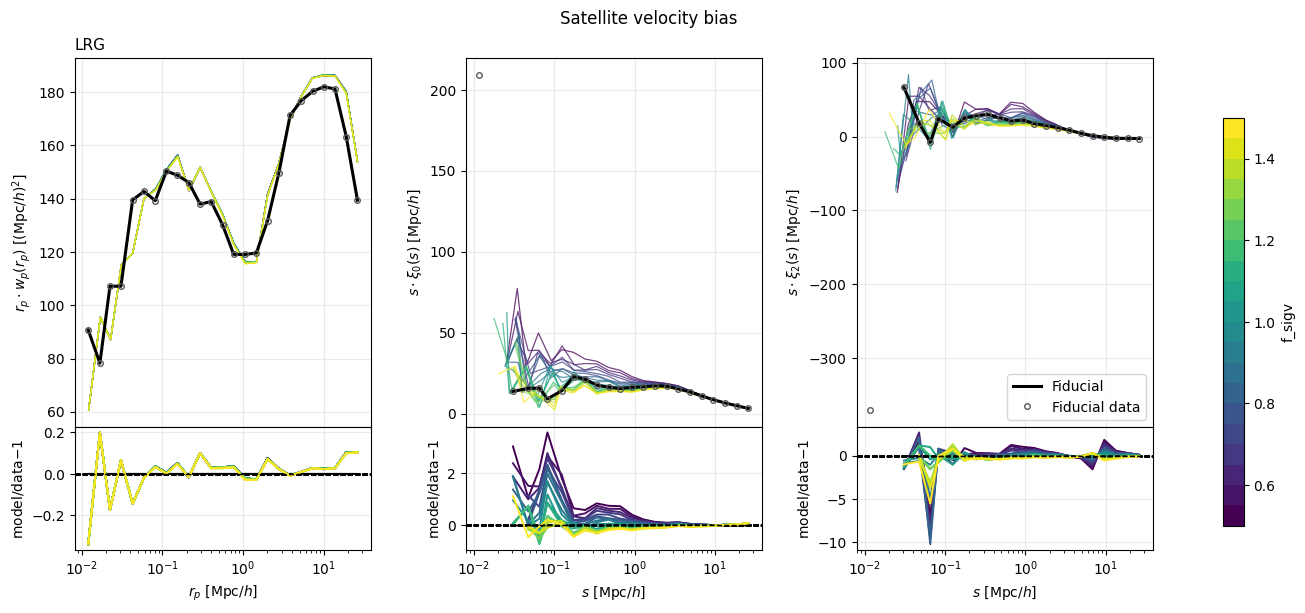

In [64]:
fig = plot_variation('f_sigv', PARAMETER_GRIDS["f_sigv"], 'Satellite velocity bias')
plt.close(fig)

[000210.62]  10-07 09:07 HOD                          INFO     Create mock catalog for ['LRG']
[000210.62]  10-07 09:07 HOD                          INFO     Run HOD for LRG
[000210.78]  10-07 09:07 HOD                          INFO     LRG mock catalogue done in 0.15 sec
[000210.78]  10-07 09:07 HOD                          INFO     Total time to create the mock catalog: 0.17 seconds
[000210.78]  10-07 09:07 HOD                          INFO     Total number of LRG: 87445 with 73387 central, 14058 satellite and a satellites fraction: 0.16
[000210.78]  10-07 09:07 HOD                          INFO     Total number of galaxies in the catalog: 87445
[000210.78]  10-07 09:07 HOD                          INFO     Total number of centrals: 73387
[000210.78]  10-07 09:07 HOD                          INFO     Total number of satellites: 14058
[000210.79]  10-07 09:07 HOD                          INFO     Compute wp for LRG...
[000210.92]  10-07 09:07 HOD                          INFO     Done

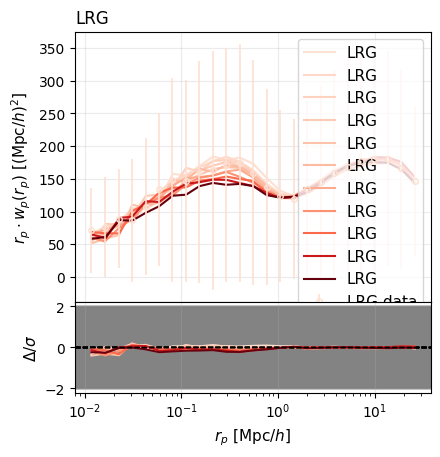

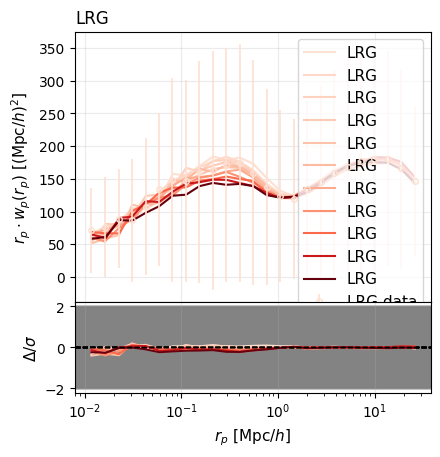

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
cmap = cm.Reds
norm = mcolors.Normalize(vmin=0, vmax=4)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig=None
HOD_model.args['LRG']['nu'] = 1
cat = HOD_model.make_mock_cat() 
rp, ds_data = HOD_model.get_wp(cat)
data = {'wp': (rp, ds_data)}

for nu in [0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,2,3,4]:
    HOD_model.args['LRG']['nu'] = nu
    cat = HOD_model.make_mock_cat()
    err = HOD_model.get_wp(cat)[1] - ds_data/ds_data
    data = {'wp': (rp, ds_data, err)}

    fig = HOD_model.plot_stats(cat, ['wp'], fig=fig, color=sm.to_rgba(nu), data=data, residuals=True)
    
fig

In [15]:
HOD_model.plot_bf_data?

Signature:
HOD_model.plot_bf_data(
    figsize=None,
    pow_sep=1,
    suptitle=None,
    suptitle_fontsize=12,
    fontsize=8,
    save_fn=None,
    fig=None,
    show=False,
    shift=0,
    max_sig=5,
    fix_seed=None,
    add_no_vsmear=False,
    save_bf_cat=None,
    **kwargs,
)
Docstring: <no docstring>
File:      ~/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/hod.py
Type:      method

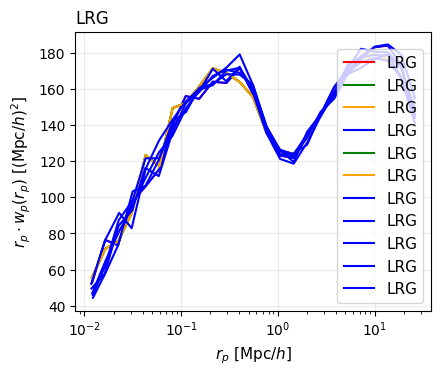

In [9]:
fig

[000013.83]  10-06 11:46 HOD                          INFO     Create mock catalog for ['LRG']
Assembly bias columns to remove: ['shear', 'c', 'env']
[000013.83]  10-06 11:46 HOD                          INFO     Run HOD for LRG
[000020.22]  10-06 11:46 HOD                          WARNING  Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.
[000026.65]  10-06 11:46 HOD                          INFO     LRG mock catalogue done in 12.81 sec
[000026.65]  10-06 11:46 HOD                          INFO     Total time to create the mock catalog: 12.83 seconds
[000026.65]  10-06 11:46 HOD                          INFO     Total number of LRG: 87730 with 73644 central, 14086 satellite and a satellites fraction: 0.16
[000026.65]  10-06 11:46 HOD                          INFO     Total number of galaxies in the catalog: 87730
[000026.65]  10-06 11:46 HOD                          INFO     Total number 

/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/hod.py:3619: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[000027.34]  10-06 11:46 HOD                          INFO     LRG mock catalogue done in 0.20 sec
[000027.35]  10-06 11:46 HOD                          INFO     Total time to create the mock catalog: 0.21 seconds
[000027.35]  10-06 11:46 HOD                          INFO     Total number of LRG: 87722 with 73644 central, 14078 satellite and a satellites fraction: 0.16
[000027.35]  10-06 11:46 HOD                          INFO     Total number of galaxies in the catalog: 87722
[000027.35]  10-06 11:46 HOD                          INFO     Total number of centrals: 73644
[000027.35]  10-06 11:46 HOD                          INFO     Total number of satellites: 14078
[000027.60]  10-06 11:46 HOD                          INFO     Create mock catalog for ['LRG']
Assembly bias columns to remove: ['shear', 'c', 'env']
[000027.61]  10-06 11:46 HOD                          INFO     Run HOD for LRG
[000027.86]  10-06 11:46 HOD                          INFO     LRG mock catalogue done in 0.26 se

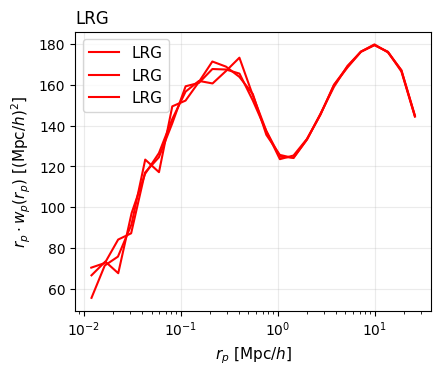

In [3]:
HOD_model.args['LRG']['nu'] = 1
cat = HOD_model.make_mock_cat(fix_seed=42)

fig = HOD_model.plot_stats(cat, ['wp'])

HOD_model.args['LRG']['nu'] = 0.99
cat = HOD_model.make_mock_cat(fix_seed=42)

fig = HOD_model.plot_stats(cat, ['wp'], fig=fig)

HOD_model.args['LRG']['nu'] = 1.01
cat = HOD_model.make_mock_cat(fix_seed=42)

fig = HOD_model.plot_stats(cat, ['wp'], fig=fig)

In [2]:
from HODDIES import HOD 
HOD_model = HOD(base_catalog=test, use_assembly_bias=False)

setup_logger True
[000003.30]  10-06 11:47 HOD                          INFO     Initializing HOD.
[000003.32]  10-06 11:47 HOD                          INFO     Set number of threads to 19


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000003.55]  10-06 11:47 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


In [12]:
test.field_particles, part_field

(<Table length=49203089>
          pos                     vel           
       float32[3]              float32[3]       
 ---------------------- ------------------------
  -249.3155 .. -230.186 -134.76562 .. -184.57031
 -249.2945 .. -230.1785  -102.53906 .. 2.9296875
   -249.266 .. -230.182     -187.5 .. -202.14844
    -249.37 .. -230.256  -125.97656 .. -84.96094
   -249.8625 .. -230.65 -266.60156 .. -43.945312
  -249.8655 .. -230.599     -205.07812 .. -93.75
   -248.972 .. -200.987  -430.66406 .. 17.578125
  -249.512 .. -199.8135 -459.96094 .. -143.55469
   -249.512 .. -199.859  -486.32812 .. 2.9296875
                    ...                      ...
  -249.9805 .. 234.9835  -99.609375 .. 172.85156
   -249.956 .. 234.9845      61.523438 .. 281.25
    -249.999 .. 234.958   -67.38281 .. 172.85156
  -249.9745 .. 234.9285    -61.523438 .. 234.375
     249.986 .. 234.946   -114.25781 .. 257.8125
    249.953 .. 234.9595     -46.875 .. 166.99219
     249.974 .. 234.962   49.804688 .. 205.0

In [26]:
cat = HOD_model.make_mock_cat()

[000559.15]  10-06 09:51 HOD                          INFO     Create mock catalog for ['LRG']
Assembly bias columns to remove: ['env', 'c', 'shear']
[000559.16]  10-06 09:51 HOD                          INFO     Run HOD for LRG
[000565.13]  10-06 09:51 HOD                          WARNING  Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.
[000570.65]  10-06 09:51 HOD                          INFO     LRG mock catalogue done in 11.49 sec
[000570.65]  10-06 09:51 HOD                          INFO     Total time to create the mock catalog: 11.51 seconds
[000570.66]  10-06 09:51 HOD                          INFO     Total number of LRG: 87405 with 73411 central, 13994 satellite and a satellites fraction: 0.16
[000570.66]  10-06 09:51 HOD                          INFO     Total number of galaxies in the catalog: 87405
[000570.66]  10-06 09:51 HOD                          INFO     Total number 

In [ ]:
cat = HOD_model.make_mock_cat()

{'HOD_model': 'SHOD',
 'Ac': 1,
 'log_Mcent': 12.75,
 'sigma_M': 0.5,
 'gamma': 1,
 'pmax': 1,
 'Q': 100,
 'satellites': True,
 'sat_HOD_model': 'Nsat_pow_law',
 'As': 1,
 'M_0': 13,
 'M_1': 13.5,
 'alpha': 1,
 'f_sigv': 1,
 'f_vcen': 0.0,
 'vel_sat': 'rd_normal',
 'v_infall': 0,
 'link_sat_to_central': False,
 'assembly_bias': {'c': [0, 0], 'env': [0, 0], 'shear': [0, 0]},
 'nu': 1.0,
 'conformity_bias': False,
 'exp_frac': 0,
 'exp_scale': 1,
 'nfw_rescale': 1,
 'density': 0.0007,
 'vsmear': 0}

[000436.24]  10-06 09:09 HOD                          INFO     Create mock catalog for ['LRG']
[000436.25]  10-06 09:09 HOD                          INFO     Run HOD for LRG
[000436.52]  10-06 09:09 HOD                          INFO     LRG mock catalogue done in 0.27 sec
[000436.52]  10-06 09:09 HOD                          INFO     Total time to create the mock catalog: 0.28 seconds
[000436.53]  10-06 09:09 HOD                          INFO     Total number of LRG: 87491 with 79141 central, 8350 satellite and a satellites fraction: 0.10
[000436.53]  10-06 09:09 HOD                          INFO     Total number of galaxies in the catalog: 87491
[000436.53]  10-06 09:09 HOD                          INFO     Total number of centrals: 79141
[000436.53]  10-06 09:09 HOD                          INFO     Total number of satellites: 8350
[000436.56]  10-06 09:09 HOD                          INFO     Compute ΔΣ for LRG...
[000437.27]  10-06 09:09 HOD                          INFO     Done i

/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/estimators/clustering_statistics.py:207: RuntimeWarning: invalid value encountered in log
  slope = np.log(wp[1:] / wp[:-1]) / np.log(rp_c[1:] / rp_c[:-1])


[000437.98]  10-06 09:09 HOD                          INFO     Done in 0.695 s
[000437.98]  10-06 09:09 HOD                          INFO     Create mock catalog for ['LRG']
[000437.98]  10-06 09:09 HOD                          INFO     Run HOD for LRG
[000438.13]  10-06 09:09 HOD                          INFO     LRG mock catalogue done in 0.14 sec
[000438.13]  10-06 09:09 HOD                          INFO     Total time to create the mock catalog: 0.15 seconds
[000438.14]  10-06 09:09 HOD                          INFO     Total number of LRG: 87112 with 77003 central, 10109 satellite and a satellites fraction: 0.12
[000438.14]  10-06 09:09 HOD                          INFO     Total number of galaxies in the catalog: 87112
[000438.14]  10-06 09:09 HOD                          INFO     Total number of centrals: 77003
[000438.14]  10-06 09:09 HOD                          INFO     Total number of satellites: 10109
[000438.16]  10-06 09:09 HOD                          INFO     Compute ΔΣ

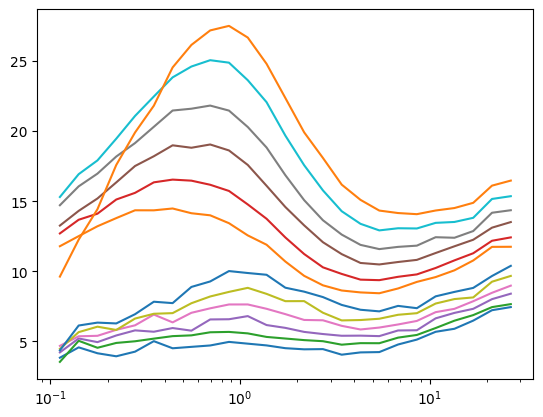

In [19]:
import matplotlib.pyplot as plt

for logM in [12.5, 12.6, 12.7, 12.8, 12.9, 13.0]:
    HOD_model.args['LRG']['log_Mcent'] = logM
    cat = HOD_model.make_mock_cat()

    HOD_model.field_particles = part_field
    rp, ds = HOD_model.get_delta_sigma(cat)

    plt.plot(rp, rp*ds)
    
    HOD_model.field_particles = test.part_subsamples
    rp, ds = HOD_model.get_delta_sigma(cat)

    plt.semilogx(rp, rp*ds)


In [15]:
HOD_model.field_particles

array([([ -41.7845, -144.3085,   82.631 ],),
       ([-203.5855,  -92.221 ,   85.624 ],),
       ([  68.1145,   52.4025, -181.855 ],), ...,
       ([-102.459 , -226.0895,  -18.643 ],),
       ([ 233.632 , -165.694 ,  -36.459 ],),
       ([-199.955 ,   79.297 ,   60.306 ],)], dtype=[('pos', '<f4', (3,))])

In [3]:
HOD_model.args['use_assembly_bias'] = True
HOD_model.args['LRG']['assembly_bias'] = {'c': [0, 0]}
HOD_model.make_mock_cat()

NameError: name 'HOD_model' is not defined

In [ ]:
HOD_model.args['LRG']['assembly_bias'] = {'c': [0, 0]}


In [28]:
from HODDIES.utils import initialize_assembly_bias_value
initialize_assembly_bias_value(HOD_model.hcat['log10_Mh'], HOD_model.hcat['c'], bins=50)

array([-0.387457    0.11612277 -0.37455815 ... -0.13895215 -0.1408613
  0.23245937])

In [3]:
HOD_model.base_catalog.set_assembly_bias_values('c')

[000004.55]  10-05 14:53 AbacusSummitSim              INFO     Set value for assembly bias according to c...
[000006.68]  10-05 14:53 AbacusSummitSim              INFO     Done !


[]

In [19]:
test.hcat, HOD_model.hcat

(Catalog(csize=6046558, size=6046558, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id']),
 Catalog(csize=6046558, size=6046558, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id']))

In [25]:
HOD_model._compute_assembly_bias_columns()

[000514.32]  10-05 14:45 AbacusSummitSim              INFO     Set value for assembly bias according to c...


ValueError: object of too small depth for desired array

In [ ]:
from sim_loader.Uchuu_io import UchuuSim

default_Uchuu_param = {'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Uchuu_sims',  # Path to halo catalogs
    'mass_cut': 11.5,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 2.03,  # Redshift of simulation snapshot
    'sim_name': 'DESIY1_DDE',  # Specific to Uchuu simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}
test=UchuuSim(**default_Uchuu_param)

[001711.94]  07-24 11:47 UchuuSim                     INFO     Initializing UchuuSim.
[001711.94]  07-24 11:47 UchuuSim                     INFO     Apply mass cut at 10^11.5 M_sol/h
[001711.94]  07-24 11:47 UchuuSim                     INFO     Can not use subhalos with Uchuu DDE simulations
[001711.94]  07-24 11:47 UchuuSim                     INFO     Load Uchuu DESIY1_DDE simulation at z=2.030 
[001711.94]  07-24 11:47 UchuuSim                     INFO     Reading ['/home/antoine/Bureau/Transfert/postdoc/Uchuu_sims/DDE/DESIY1_DDE/out_1.rockstar.h5']


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[001712.89]  07-24 11:47 UchuuSim                     INFO     Reading file /home/antoine/Bureau/Transfert/postdoc/Uchuu_sims/DDE/DESIY1_DDE/out_1.rockstar.h5
[001737.29]  07-24 11:47 UchuuSim                     INFO     Uchuu catalogue read in 25.35 seconds


In [ ]:
from hod import HOD
from sim_loader import Base_catalogue, setup_logging
import numpy as np
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}

def test_catalogue(N=1_000_000, boxsize=1000):
    np.random.seed(42)
    x,y,z = np.random.uniform(0, 1, (3, N)) * boxsize  # Generate a random catalogue of N points in a boxsize x boxsize x boxsize box
    vx,vy,vz = np.random.normal(0, 300, (3, N))  # Generate random velocities for each point
    id = np.arange(N)  # Generate unique IDs for each point
    mass = 10**np.random.uniform(11, 15, N)  # Generate random masses for each point
    rh = np.random.uniform(100, 2000, N)  # Generate random halo radii for each point
    vrms = np.random.uniform(100, 500, N)  # Generate random vrms for each point
    conc = np.random.normal(4, 2, N)  # Generate random concentrations for each point
    conc[conc < 0] = 0.1  # Set negative concentrations to a small positive value
    cat = dict(xx=x, yy=y, zz=z, vxx=vx, vyy=vy, vzz=vz, halo_iid=id, Mhh=mass, Rhh=rh, Vrrms=vrms, cc=conc, uu=x)
    return cat
setup_logging()
cat = test_catalogue(N=1_000_000, boxsize=1000)
from astropy.table import Table
test=Base_catalogue(halo_data=Table(cat), boxsize=1000, z_simu=0.5, mapping_halo_cols={'x':'xx', 'y':'yy', 'z':'zz', 'vx':'vxx', 'vy':'vyy', 'vz':'vzz', 'halo_id':'halo_iid', 'Mh':'Mhh', 'Rh':'Rhh', 'Vrms':'Vrrms', 'c':'cc', 'uu':'uu'})

[000000.13]  07-23 13:28 Base_catalogue               INFO     Initializing Base_catalogue.


In [ ]:
HOD_model = HOD(base_catalog=test, param_file='/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/default_HOD_parameters.yaml', use_assembly_bias=False, use_particles=False)

Set number of threads to 18
Initialize Abacus c000 cosmology


In [11]:
from sim_loader.abacus_io import AbacusSummitSim
from hod import HOD
from sim_loader import setup_logging

setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': False,  # Whether to load particle/subhalos data
}
# test=AbacusSummitSim(**default_abacus_param)

HOD_model = HOD(base_catalog=test, param_file='/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/default_HOD_parameters.yaml', use_assembly_bias=False, use_particles=True)

[000000.00]  07-29 16:47 HOD                          INFO     Initializing HOD.
[000000.02]  07-29 16:47 HOD                          INFO     Set number of threads to 19
[000000.02]  07-29 16:47 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


[000170.31]  07-29 16:50 HOD                          INFO     Create mock catalog for ['LRG']
[000170.31]  07-29 16:50 HOD                          INFO     Run HOD for LRG
[000170.50]  07-29 16:50 HOD                          INFO     LRG mock catalogue done in 0.19 sec
[000170.51]  07-29 16:50 HOD                          INFO     Total time to create the mock catalog: 0.20 seconds
[000170.51]  07-29 16:50 HOD                          INFO     Total number of LRG: 87470 with 65836 central, 21634 satellite and a satellites fraction: 0.25
[000170.51]  07-29 16:50 HOD                          INFO     Total number of galaxies in the catalog: 87470
[000170.51]  07-29 16:50 HOD                          INFO     Total number of centrals: 65836
[000170.51]  07-29 16:50 HOD                          INFO     Total number of satellites: 21634
[000170.52]  07-29 16:50 HOD                          INFO     Compute PS for LRG...
[000170.52]  07-29 16:50 CatalogFFTPower              INFO     Pain

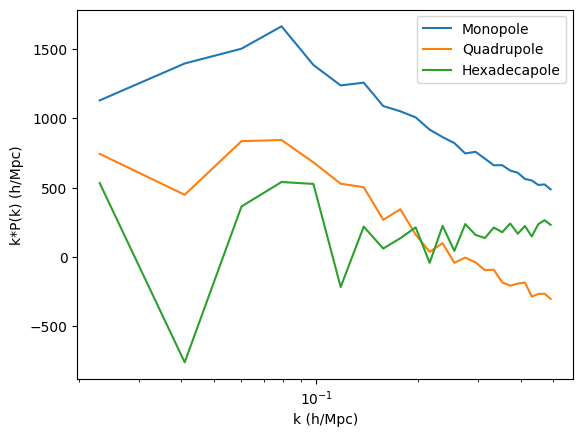

In [17]:

cat = HOD_model.make_mock_cat('LRG', fix_seed=  42)
    
import matplotlib.pyplot as plt
k, Pk = HOD_model.get_PS(cat, ells=[0,2,4], verbose=True)
plt.plot(k, k*Pk[0], label='Monopole')
plt.plot(k, k*Pk[1], label='Quadrupole')
plt.plot(k, k*Pk[2], label='Hexadecapole')
plt.xscale('log')
plt.xlabel('k (h/Mpc)')
plt.ylabel('k*P(k) (h/Mpc)')
plt.legend()
plt.show()


In [3]:
from estimators.clustering_statistics import compute_power_spectrum

In [9]:
res = compute_power_spectrum(pos1=[cat['x']%500, cat['y']%500, cat['z']%500], boxsize=HOD_model.boxsize, kedges=kedges, los='z', nmesh=128, resampler='tsc', interlacing=2, ells=(0, 2,4,6))

[000113.43]  07-29 16:22 CatalogFFTPower              INFO     Painting catalog 1 to mesh CatalogMesh(nmesh=[128 128 128], boxsize=[500. 500. 500.], boxcenter=[250.00069957 249.99922677 250.00422814], dtype=float64).
[000113.43]  07-29 16:22 CatalogMesh                  INFO     Slab 0 ~ 4194304 / 87470.
[000113.59]  07-29 16:22 CatalogMesh                  INFO     Painted 87470 out of 87470 objects to mesh.
[000113.59]  07-29 16:22 CatalogMesh                  INFO     Running interlacing at order 2.
[000113.62]  07-29 16:22 CatalogMesh                  INFO     Slab 0 ~ 4194304 / 87470.
[000113.77]  07-29 16:22 CatalogMesh                  INFO     Painted 87470 out of 87470 objects to mesh.
[000113.85]  07-29 16:22 CatalogFFTPower              INFO     Done painting catalog 1 to mesh.
[000113.85]  07-29 16:22 CatalogFFTPower              INFO     Using 10 k-bins between 0.000 and 0.200.
[000113.85]  07-29 16:22 CatalogFFTPower              INFO     Meshes prepared in elapsed time 0

In [11]:
res.poles(ell=ells, return_k=True, complex=False)

(array([0.01519245, 0.03319736, 0.05172891, 0.07059358, 0.09026194,
        0.11110575, 0.1307922 , 0.15046594, 0.17055374, 0.19026058]),
 array([[ 3.10128403e+04,  3.33591477e+04,  2.08283239e+04,
          1.93822230e+04,  1.31234276e+04,  9.37756556e+03,
          7.85775091e+03,  6.56419994e+03,  5.78733239e+03,
          4.81785957e+03],
        [-4.08916392e+03, -1.35297062e+03,  2.96197504e+03,
          7.45403810e+02,  2.71317674e+03, -9.07752546e+02,
          6.03660662e+02,  2.88173225e+02,  2.83614388e+01,
          8.92733954e+01],
        [-3.26377762e+04,  5.84984816e+03,  2.54951692e+03,
          4.58667655e+03, -2.11454580e+02,  1.21729743e+03,
         -5.92128509e+02,  5.85027820e+02,  7.34773806e+02,
         -3.50902061e+02]]))

In [3]:
from hod import HOD
from sim_loader.abacus_io import AbacusSummitSim
from sim_loader import setup_logging

default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}
setup_logging()
test=AbacusSummitSim(**default_abacus_param)
HOD_model = HOD(base_catalog=test, use_assembly_bias=False, use_particles=False, tracers='Halpha', clustering_settings={})


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000000.00]  07-29 15:07 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.00]  07-29 15:07 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...


/home/antoine/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


[000003.01]  07-29 15:07 AbacusSummitSim              INFO     Done took 00:00:03
[000003.01]  07-29 15:07 AbacusSummitSim              INFO     Compute required columns...
[000003.11]  07-29 15:07 AbacusSummitSim              INFO     Done took 00:00:00
[000003.11]  07-29 15:07 HOD                          INFO     Initializing HOD.
[000003.12]  07-29 15:07 HOD                          INFO     Set number of threads to 19
[000003.12]  07-29 15:07 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


[000056.40]  07-29 15:08 HOD                          INFO     Create mock catalog for ['Halpha']
[000056.40]  07-29 15:08 HOD                          INFO     Run HOD for Halpha
[000056.53]  07-29 15:08 HOD                          INFO     Halpha mock catalogue done in 0.13 sec
[000056.53]  07-29 15:08 HOD                          INFO     Total time to create the mock catalog: 0.14 seconds
[000056.54]  07-29 15:08 HOD                          INFO     Total number of Halpha: 86893 with 70519 central, 16374 satellite and a satellites fraction: 0.19
[000056.54]  07-29 15:08 HOD                          INFO     Total number of galaxies in the catalog: 86893
[000056.54]  07-29 15:08 HOD                          INFO     Total number of centrals: 70519
[000056.54]  07-29 15:08 HOD                          INFO     Total number of satellites: 16374
[000056.55]  07-29 15:08 HOD                          INFO     Compute ΔΣ for Halpha...
[000056.57]  07-29 15:08 TwoPointCorrelationFunction

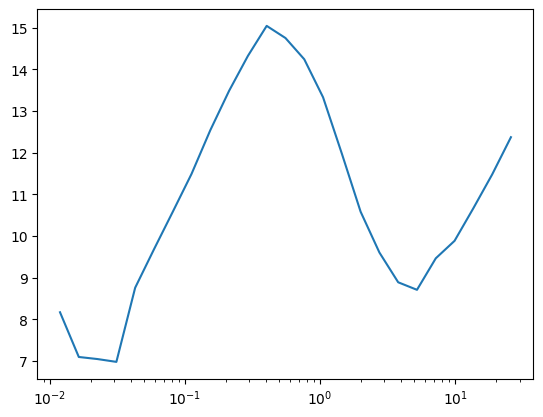

In [ ]:
# HOD_model.args['use_particles'] = False
HOD_model.args['Halpha']['HOD_model'] = 'mHMQ'

cat = HOD_model.make_mock_cat(fix_seed=42)   
    
import matplotlib.pyplot as plt
rp, wp = HOD_model.get_delta_sigma(cat)
plt.plot(rp, rp*wp)
plt.xscale('log')


[000802.94]  07-29 15:20 HOD                          INFO     Create mock catalog for ['Halpha']
[000802.95]  07-29 15:20 HOD                          INFO     Run HOD for Halpha
[000803.15]  07-29 15:20 HOD                          INFO     Halpha mock catalogue done in 0.20 sec
[000803.15]  07-29 15:20 HOD                          INFO     Total time to create the mock catalog: 0.21 seconds
[000803.16]  07-29 15:20 HOD                          INFO     Total number of Halpha: 86893 with 70519 central, 16374 satellite and a satellites fraction: 0.19
[000803.16]  07-29 15:20 HOD                          INFO     Total number of galaxies in the catalog: 86893
[000803.16]  07-29 15:20 HOD                          INFO     Total number of centrals: 70519
[000803.16]  07-29 15:20 HOD                          INFO     Total number of satellites: 16374


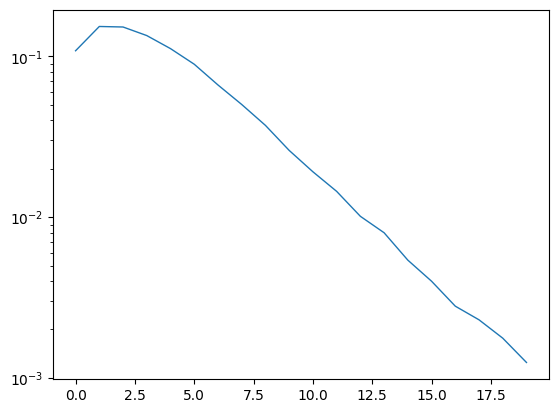

In [14]:
# HOD_model.args['use_particles'] = False
HOD_model.args['Halpha']['HOD_model'] = 'mHMQ'

cat = HOD_model.make_mock_cat(fix_seed=42)   
    
import matplotlib.pyplot as plt
import numpy as np
cic_edges = np.arange(-0.5, 20)
counts = HOD_model.get_CIC(cat, 'Halpha')
cic_cens = 0.5 * (cic_edges[:-1] + cic_edges[1:])
cic_counts = np.histogram(counts, bins=cic_edges, density=True)[0]
plt.plot(cic_cens, cic_counts, label="data", lw=1)
plt.yscale('log')


In [9]:
counts

[array([ 3,  4,  1, ...,  2,  2, 12], dtype=int32)]

In [2]:
HOD_model.get_cross2PCF(cat, 'Halpha', ells=0)

NameError: name 'HOD_model' is not defined

In [9]:
HOD_model.check_clustering_settings('xi_rppi')

In [13]:
HOD_model.args['clustering_settings']

{'rsd': True,
 'los': 'z',
 'xi_rppi': {'bin_logscale': True,
  'pimax': 40,
  'n_rp_bins': 25,
  'rp_max': 30,
  'rp_min': 0.01,
  'edges_rppi': (array([1.00000000e-02, 1.37747857e-02, 1.89744720e-02, 2.61369285e-02,
          3.60030589e-02, 4.95934420e-02, 6.83139034e-02, 9.41009377e-02,
          1.29622025e-01, 1.78551561e-01, 2.45950949e-01, 3.38792160e-01,
          4.66678939e-01, 6.42840237e-01, 8.85498648e-01, 1.21975541e+00,
          1.68018693e+00, 2.31442149e+00, 3.18806600e+00, 4.39149258e+00,
          6.04918691e+00, 8.33262532e+00, 1.14780128e+01, 1.58107166e+01,
          2.17789233e+01, 3.00000000e+01]),
   array([-40., -39., -38., -37., -36., -35., -34., -33., -32., -31., -30.,
          -29., -28., -27., -26., -25., -24., -23., -22., -21., -20., -19.,
          -18., -17., -16., -15., -14., -13., -12., -11., -10.,  -9.,  -8.,
           -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,
            4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,  12., 

In [12]:
import yaml 
import os
tt = yaml.load(open(os.path.join('statistics/default_clustering_parameters.yaml')), Loader=yaml.FullLoader)

In [13]:
tt.get('xi_rppi', None)

[000029.10]  07-27 15:20 HOD                          INFO     Create mock catalog for ['LRG']
[000029.11]  07-27 15:20 HOD                          INFO     Run HOD for LRG
[000029.23]  07-27 15:20 HOD                          WARNING  Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.
[000035.93]  07-27 15:21 HOD                          INFO     LRG mock catalogue done in 6.82 sec
[000035.93]  07-27 15:21 HOD                          INFO     Total time to create the mock catalog: 6.83 seconds
[000035.93]  07-27 15:21 HOD                          INFO     Total number of LRG: 87470 with 65836 central, 21634 satellite and a satellites fraction: 0.25
[000035.93]  07-27 15:21 HOD                          INFO     Total number of galaxies in the catalog: 87470
[000035.93]  07-27 15:21 HOD                          INFO     Total number of centrals: 65836
[000035.93]  07-27 15:21 HOD          

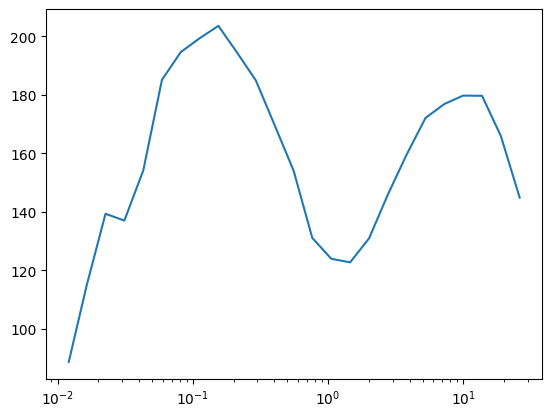

In [ ]:
HOD_model.args['use_particles'] = False
cat = HOD_model.make_mock_cat('LRG', fix_seed=42)

import matplotlib.pyplot as plt
rp, wp = HOD_model.get_wp(cat)
plt.plot(rp, rp*wp)
plt.xscale('log')


In [ ]:
HOD_model.base_catalog.part_subsamples

pos,vel
float32[3],float32[3]
-249.3155 .. -230.186,-134.76562 .. -184.57031
-249.2945 .. -230.1785,-102.53906 .. 2.9296875
-249.266 .. -230.182,-187.5 .. -202.14844
-249.37 .. -230.256,-125.97656 .. -84.96094
-249.8625 .. -230.65,-266.60156 .. -43.945312
-249.8655 .. -230.599,-205.07812 .. -93.75
-248.972 .. -200.987,-430.66406 .. 17.578125
-249.512 .. -199.8135,-459.96094 .. -143.55469
-249.512 .. -199.859,-486.32812 .. 2.9296875


In [ ]:
HOD_model.args['use_particles'] = False
cat1 = HOD_model.make_mock_cat('LRG', fix_seed=42)
import matplotlib.pyplot as plt
rp1, wp1 = HOD_model.get_wp(cat1)
plt.plot(rp1, rp1*wp1)
plt.plot(rp, rp*wp)
plt.xscale('log')

NameError: name 'HOD_model' is not defined

In [ ]:

HOD_model.args['use_assembly_bias'] = True
HOD_model.args['use_particles'] = False
cat = HOD_model.make_mock_cat()
cat


Create mock catalog for ['LRG', 'ELG']
Run HOD for LRG
Set density to 0.0007 gal/Mpc/h
Initialisation in 0.09 sec
Ncent, Nsat computed in 0.58 sec
Central catalog in 0.02 sec
HOD computed for LRG in 0.68 sec
Start satellite assignement
NFW satellite assignment done 0.0022735595703125
Satellite assignement done 0.047756195068359375
Make final catalog
LRG mock catalogue done 0.7380211353302002
Run HOD for ELG
Set density to 0.001 gal/Mpc/h
Initialisation in 0.02 sec
Ncent, Nsat computed in 0.52 sec
Central catalog in 0.01 sec
HOD computed for ELG in 0.55 sec
Start satellite assignement
NFW satellite assignment done 0.004872798919677734
Satellite assignement done 0.08231425285339355
Make final catalog
ELG mock catalogue done 0.6386406421661377
Total time to create the mock catalog: 1.48 seconds
Total number of LRG: 87246 with 65715 central, 21531 satellite and a satellites fraction: 0.25
Total number of ELG: 125037 with 50384 central, 74653 satellite and a satellites fraction: 0.60
Total 

Catalog(csize=212283, size=212283, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id', 'ab_c', 'env', 'shear', 'ab_env', 'Central', 'TRACER'])

In [ ]:
HOD_model.compute_stat(cat, 'xi_smu', tracers=['LRG'], verbose=True)

#Compute xi(smu) for ['LRG' 'LRG']...
[000955.03]  07-24 17:15 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000955.03]  07-24 17:15 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[000955.03]  07-24 17:15 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000955.56]  07-24 17:15 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[000955.57]  07-24 17:15 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.53 s.
#Done in 0.572 s


{'LRG_LRG': <pycorr.twopoint_estimator.NaturalTwoPointEstimator at 0x71dc13c15ed0>}

In [ ]:
cat = test_catalogue(N=1000, boxsize=1000)


NameError: name 'test_catalogue' is not defined

In [ ]:
from utils import * 

def __init_hod_param(self, tracer):

        """
        Initialize the HOD (Halo Occupation Distribution) parameters for mock galaxy creation based on the selected HOD model.

        Parameters
        ----------
        tracer : str
            The key identifying the specific tracer (e.g., galaxy type) for which the HOD parameters will be initialized. Need to be in self.tracers
        
        Returns
        -------
        tuple
            A tuple containing:
            - np.float64 array of central galaxy parameters (hod_list_param_cen).
            - np.array of satellite galaxy parameters if applicable (hod_list_param_sat).
            - np.array of assembly bias parameters if applicable (hod_param_ab).

        Raises
        ------
        ValueError
            If the provided HOD model is not recognized or supported.
        
        Notes
        -----
        The function handles the following HOD models:
            - 'HMQ': Central galaxy parameters with specific components.
            - 'GHOD', 'LNHOD', 'SHOD': Central galaxy parameters with different components.
            - 'SFHOD', 'mHMQ': Central galaxy parameters with a 'gamma' component.
        
        Satellite galaxy parameters are initialized if 'satellites' is set to True, 
        and assembly bias parameters are initialized if 'assembly_bias' is provided.

        Example
        -------
        For a given 'tracer' (e.g., 'galaxy'), the function might initialize:
        - Central parameters: [Ac, log_Mcent, sigma_M, gamma, Q, pmax]
        - Satellite parameters: [As, M_0, M_1, alpha]
        - Assembly bias parameters: List derived from the 'assembly_bias' dictionary.
        """

        hod_list_param_sat, hod_param_ab = None, None
        hod_list_param_cen = [self.args[tracer][name] for name in self._cen_param_names(self.args[tracer]['HOD_model'])]

        if self.args[tracer]['satellites']:
            hod_list_param_sat = np.array([self.args[tracer][name] for name in self._sat_param_names(self.args[tracer]['sat_HOD_model'])], dtype='float64')

        if self.args['use_assembly_bias']:
            hod_param_ab = np.array(list(self.args[tracer]['assembly_bias'].values()), dtype='float64').T

        return np.float64(hod_list_param_cen), hod_list_param_sat, hod_param_ab

@njit(parallel=True, fastmath=True)
def compute_N(log10_Mh, fun_cHOD, fun_sHOD, p_cen, p_sat, nu=1, p_ab=None, Nthread=32, ab_arr=None, weight=None, conformity=False, link_sat_to_central=False, seed=None):
    """
    Compute the number of central and satellite galaxies in a halo using a HOD (Halo Occupation Distribution) model.

    Parameters:
        log10_Mh : ndarray
            Logarithmic mass of halos.
        fun_cHOD : callable
            Function to compute central occupation based on halo mass.
        fun_sHOD : callable
            Function to compute satellite occupation based on halo mass.
        p_cen : ndarray
            Parameters for the central HOD function.
        p_sat : ndarray
            Parameters for the satellite HOD function.
        p_ab : ndarray or None, optional
            Assembly bias parameters (central and satellite). Default is None.
        Nthread : int, optional
            Number of threads to use in parallel computation. Default is 32.
        ab_arr : ndarray or None, optional
            Assembly bias array per halo. Default is None.
        conformity : bool, optional
            Whether satellite number is correlated with central galaxy presence. Default is False.
        seed : ndarray or None, optional
            Seed array for RNG per thread. Default is None.

    Returns:
        Ncent : ndarray
            Expected number of central galaxies.
        N_sat : ndarray
            Expected number of satellite galaxies.
        cond_cent : ndarray
            Boolean array indicating presence of a central galaxy.
        proba_sat : ndarray
            Sampled number of satellites per halo.
    """

    
    numba.set_num_threads(Nthread)
    # starting index of each thread
    hstart = np.rint(np.linspace(0, len(log10_Mh), Nthread + 1))
    cond_cent = np.zeros(log10_Mh.size, dtype=np.bool_)
    proba_sat = np.empty_like(log10_Mh, dtype=np.int64)
    Ncent = np.empty_like(log10_Mh, dtype=np.float64)
    Nb_sat = 0


    # figuring out the number of halos kept for each thread
    for tid in numba.prange(Nthread):
        if seed is not None:
            np.random.seed(seed[tid])
        for i in range(int(hstart[tid]), int(hstart[tid + 1])):
            Ncent[i] = fun_cHOD(log10_Mh[i], p_cen)
            if p_ab is not None:
                Ncent[i] *= (1 + np.sum(p_ab[0] * ab_arr[i])*(1-Ncent[i]))
            cond_cent[i] = Ncent[i] * weight[i] - np.random.uniform(0, 1) > 0
            if p_sat is not None:
                N_sat = fun_sHOD(log10_Mh[i], p_sat)
                if link_sat_to_central:
                    N_sat *= Ncent[i]
                if p_ab is not None:
                    N_sat *= (1 + np.sum(p_ab[1] * ab_arr[i]))
                if N_sat <=0:
                    proba_sat[i] = 0
                elif conformity:
                    proba_sat[i] = np.random.poisson(N_sat*cond_cent[i])
                else :
                    if nu == 1:
                        proba_sat[i] = np.random.poisson(N_sat)
                    else:
                        proba_sat[i] = cmp_sample(N_sat, nu)
                if proba_sat[i] > 0:
                    Nb_sat += proba_sat[i]
                    
    return Ncent, cond_cent, proba_sat, Nb_sat


def make_mock_cat(self, tracers=None, fix_seed=None, verbose=True):
    """
    Generate HOD mock catalogs.

    This method creates mock galaxy catalogs based on the Halo Occupation Distribution (HOD) model for each 
    specified tracer. It computes the central and satellite galaxies, assigns them to halos, and optionally 
    includes assembly bias effects, conformity bias, and uses particle-level data for satellite galaxy 
    positions. It handles multiple tracers and provides options for reproducibility and verbose output.

    Parameters
    ----------
    tracers : list or str, optional
        Name(s) of the galaxy tracers (e.g., 'LRG', 'ELG') to include in the mock catalog. If None, all 
        tracers defined in `self.tracers` are considered. Defaults to None.
    fix_seed : int, optional
        Fix the seed for reproducibility. This is useful for ensuring consistent results when using a fixed 
        number of threads (`nthreads`). Defaults to None.
    verbose : bool, optional
        If True, the function prints progress messages during execution. Defaults to True.

    Returns
    -------
    final_cat : dict
        A dictionary containing mock catalogs for each tracer specified. Each catalog is represented by a `Catalog`
        object, which contains the generated galaxy data (centrals and satellites) for the corresponding tracer.

    Notes
    -----
    - The method relies on HOD models defined for each tracer in `self.args[tracer]['HOD_model']` and `self.args[tracer]['sat_HOD_model']`.
    - If `self.args['assembly_bias']` is enabled, assembly bias columns will be computed and included in the mock catalog.
    - The `fix_seed` parameter ensures that the mock catalogs are generated in a reproducible manner, but it requires consistent 
    thread configurations (`self.nthreads`).
    - When `tracers` includes both 'ELG' and 'LRG', the method handles the case where both tracers share the same halo by placing
    one LRG at the center and positioning other galaxies (like ELGs) based on the NFW profile.

    Example
    -------
    To generate mock catalogs for both 'LRG' and 'ELG' tracers with fixed seed for reproducibility:

    final_cat = mock_catalog.make_mock_cat(tracers=['LRG', 'ELG'], fix_seed=42)
    """

    rng = np.random.RandomState(seed=fix_seed)
    start_all = time.time()
    
    if tracers is None: 
        tracers = self._tracers()
    else:
        tracers = tracers if isinstance(tracers, list) else [tracers]
        for tr in tracers:
            if tr not in self._tracers():
                raise ValueError(f'{tr} not in defined tracers {self._tracers()}')
    # Fail early with a clear message if any required HOD parameter is missing.
    self.check_HOD_params(tracers)
    if verbose:
        print('Create mock catalog for {}'.format(tracers), flush=True)         
    
    if self.args['use_assembly_bias']:
        self._compute_assembly_bias_columns()

    final_cat = {}
    # mask_id = np.ones(self.hcat.size, dtype=bool)
    # count_gal = {}
    # Check if we have more than one tracer to determine if we need to compute weights for the halo mass function.
    if len(tracers) > 1:
        weight = np.ones(self.hcat['log10_Mh'].size, dtype=np.float64)
        cc, bins = np.histogram(self.hcat['log10_Mh'], bins=100)
    else:
        weight = None
    
    for tracer in tracers:
        start = time.time()
        self._fun_cHOD[tracer] = getattr(HOD_models, '_'+self.args[tracer]['HOD_model'])
        self._fun_sHOD[tracer] = getattr(HOD_models, '_'+self.args[tracer]['sat_HOD_model'])
        if verbose:
            print('Run HOD for {}'.format(tracer), flush=True)         
        hod_list_param_cen, hod_list_param_sat, hod_list_ab_param = __init_hod_param(self, tracer)
        
        ds = self.get_ds_fac(tracer, verbose=verbose)
        if (hod_list_param_cen[0]*ds > 1):
            import warnings
            warnings.warn('Ac={} is > 1, the density is not fixed to {}'.format(hod_list_param_cen[0]*ds, self.args[tracer]["density"]))
        else : 
            hod_list_param_cen[0] *= ds
            hod_list_param_sat[0] *= 1 if self.args[tracer]['link_sat_to_central'] else ds

        if fix_seed is not None:
            seed = rng.randint(0, 4294967295, self.nthreads)
        else:
            seed = None
        
        if self.args['use_assembly_bias'] & (hod_list_ab_param is not None):
            cols_ab =  ['ab_'+col for col in self.args[tracer]['assembly_bias'].keys()]
            if np.all([col in self.hcat.columns() for col in cols_ab]):
                ab_arr =  np.vstack([self.hcat[col] for col in cols_ab]).T
            else:
                import warnings
                warnings.warn('Precomputed columns for assembly bias have not been found {}. Continue without assembly bias.'.format(cols_ab))
                hod_list_ab_param=None
        else:
            hod_list_ab_param, ab_arr = None, None
        if verbose:
            print("Initialisation in {:.2f} sec".format(time.time()-start), flush=True)
            st = time.time()
        
        cond_cent, proba_sat, Nb_sat = compute_N(self.hcat['log10_Mh'], self._fun_cHOD[tracer], self._fun_sHOD[tracer], hod_list_param_cen, 
                                                hod_list_param_sat, self.args[tracer]['nu'], hod_list_ab_param, self.nthreads, ab_arr, weight,
                                                self.args[tracer]['conformity_bias'], self.args[tracer]['link_sat_to_central'], seed)
        if verbose:
            print('Ncent, Nsat computed in {:.2f} sec'.format(time.time()-st), flush=True)
            st = time.time()

        mm = weight > 0
        cc_1, bins = np.histogram(self.hcat['log10_Mh'][~cond_cent & mm], bins=bins)
        idx = np.digitize(self.hcat['log10_Mh'][~cond_cent & mm], bins) - 1    # -1 because digitize is 1-based
        idx = np.clip(idx, 0, len(cc) - 1)  # guard the rightmost edge

        weight[cond_cent] = 0
        weight[weight > 0] = ( cc / cc_1 )[idx]                    # one value per element of `masses`
        
        cent_cat = self.hcat[cond_cent]
        cent_cat['Central'] = np.ones(cent_cat['x'].size,dtype='int')

        if verbose:
            print('Central catalog in {:.2f} sec'.format(time.time()-st), flush=True)
            print("HOD computed for {} in {:.2f} sec".format(tracer, time.time()-start), flush=True)
        
        if (not self.args[tracer]['satellites']) | (Nb_sat == 0):
            Nb_sat=0
            final_cat[tracer] = cent_cat
            final_cat[tracer]['TRACER'] = [tracer]*final_cat[tracer].size
            
        else:
            start_sat = time.time()
            if verbose:
                print("Start satellite assignement", flush=True)
            mask_sat = proba_sat > 0
            list_nsat = proba_sat[mask_sat]
            # sat_cat = Catalog.from_array(np.repeat(self.hcat[mask_sat].to_array(), list_nsat))
            sat_cat = Catalog()
            sat_cat.data = {col: np.repeat(self.hcat[mask_sat][col], list_nsat) for col in self.hcat.columns()}
            
            if self.args['use_particles'] & (self.part_subsamples is not None):
                if verbose: print('Using particles', flush=True)
                if self.base_catalog._is_sim_abacus:
                    if verbose: 
                        print('Using Abacus particles', flush=True)
                        start = time.time()
                    if fix_seed is not None:
                        seed = rng.randint(0, 4294967295, self.nthreads)
                    else:
                        seed = None
                    mask_nfw = compute_sat_from_abacus_part(self.part_subsamples['pos'].T[0],self.part_subsamples['pos'].T[1],self.part_subsamples['pos'].T[2],
                        self.part_subsamples['vel'].T[0], self.part_subsamples['vel'].T[1],self.part_subsamples['vel'].T[2],
                        sat_cat['x'], sat_cat['y'], sat_cat['z'], sat_cat['vx'], sat_cat['vy'], sat_cat['vz'],
                        self.hcat['npoutA'][mask_sat], self.hcat['npstartA'][mask_sat], list_nsat, np.insert(np.cumsum(list_nsat), 0, 0), self.nthreads, seed=seed)
                    if verbose: 
                        print('sat from part done', time.time() - start, flush=True)
                        print(f'{mask_nfw.sum()} satellites will be positioned using NFW', flush=True)

                else:
                    if fix_seed is not None:
                        seed = rng.randint(0, 4294967295, sat_cat.size)
                    else:
                        seed = None
                    start = time.time()
                    start_part = time.time()
                    uniq_sat_id = np.unique(sat_cat['halo_id'])
                    if not hasattr(self, '_order_part_index'):
                        self._order_part_index = np.argsort(self.part_subsamples['halo_id'])
                    flat, offsets = halo_to_particle_indices(self.part_subsamples['halo_id'][self._order_part_index], self._order_part_index, uniq_sat_id, self.nthreads)
                    # result = [flat[offsets[i]:offsets[i+1]] for i in range(len(uniq_sat_id))]
                    start = time.time()
                    sat_cat = sat_cat[sat_cat['halo_id'].argsort()]
                    start = time.time()
                    
                    mask_nfw = sample_satellites_from_particles(sat_cat['x'], sat_cat['y'], sat_cat['z'], sat_cat['vx'], sat_cat['vy'], sat_cat['vz'],
                                                        self.part_subsamples['x'], self.part_subsamples['y'], self.part_subsamples['z'],
                                                        self.part_subsamples['vx'], self.part_subsamples['vy'], self.part_subsamples['vz'], flat, offsets,
                                                        list_nsat, self.nthreads, seed=seed)
                    if verbose: 
                        print('sample_satellites_from_particles done', time.time() - start, flush=True)
                        print('sat from part done', time.time() - start_part, flush=True)
                        print(f'{mask_nfw.sum()} satellites will be positioned using NFW', flush=True)
            
            else:
                if self.args['use_particles']:
                    import warnings
                    warnings.warn('use_particles is set to True but no particle subsample found, continue with NFW profile for satellites')
                if self.part_subsamples is not None:
                    import warnings
                    warnings.warn('Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.')
                mask_nfw = np.ones(Nb_sat, dtype=bool)
                
            
            if mask_nfw.sum() > 0:
                start = time.time()
                if fix_seed is not None:
                    seed1 = rng.randint(0, 4294967295, self.nthreads)
                else:
                    seed1 = None
                rd_pos = getPointsOnSphere_jit(Nb_sat, np.minimum(Nb_sat, self.nthreads), seed1)
                if self.args[tracer]['vel_sat'] == 'NFW':
                    seed2 = rng.randint(0, 4294967295, self.nthreads)
                    rd_v = getPointsOnSphere_jit(Nb_sat, np.minimum(Nb_sat, self.nthreads), seed2)
                    ut = np.cross(rd_pos,rd_v, axis=1) 
                    rd_vel = (ut.T / np.linalg.norm(ut, axis=1).flatten()).T
                else:
                    rd_vel = np.ones_like(rd_pos)
                
                vrms_h = sat_cat['Vrms'][mask_nfw] if 'Vrms' in sat_cat.columns() else np.zeros_like(sat_cat['vx'][mask_nfw])

                sat_cat['x'][mask_nfw], sat_cat['y'][mask_nfw], sat_cat['z'][mask_nfw], \
                sat_cat['vx'][mask_nfw], sat_cat['vy'][mask_nfw], sat_cat['vz'][mask_nfw] = compute_fast_NFW(sat_cat['x'][mask_nfw], sat_cat['y'][mask_nfw], sat_cat['z'][mask_nfw],
                sat_cat['vx'][mask_nfw], sat_cat['vy'][mask_nfw], sat_cat['vz'][mask_nfw],
                sat_cat['c'][mask_nfw], sat_cat['Mh'][mask_nfw], sat_cat['Rh'][mask_nfw], 
                rd_pos, rd_vel, exp_frac=self.args[tracer]['exp_frac'], 
                exp_scale=self.args[tracer]['exp_scale'], nfw_rescale=self.args[tracer]['nfw_rescale'],
                vrms_h=vrms_h, f_sigv=self.args[tracer]['f_sigv'], v_infall=self.args[tracer]['v_infall'], 
                vel_sat=self.args[tracer]['vel_sat'], Nthread=self.nthreads, seed=seed)
                if verbose:
                    print("NFW Computed", time.time() - start, flush=True)
            sat_cat['Central'] = sat_cat.zeros()

            if verbose:
                print("Satellite assignement done", time.time() - start_sat, flush=True)

            if verbose:
                print("Make final catalog", flush=True)
                start = time.time()
            final_cat[tracer] = Catalog.concatenate((cent_cat,sat_cat))
            # final_cat[tracer]['TRACER'] = [tracer]*final_cat[tracer].size
            final_cat[tracer]['TRACER'] = np.full(final_cat[tracer].size, tracer)
            if verbose:
                print('{} mock catalogue done'.format(tracer), time.time()-start, flush=True)
                
            
        # mask_id &= (mask_cent | mask_sat)
        # count_gal[tracer] = np.int64(proba_sat + cond_cent)

        if verbose:
            print("Done overall time ", tracer, time.time() - start_all, flush=True)

    # When LRG and ELG are in the same halo, put 1 LRG at the center and all other galaxies are position following NFW profile
    # if ((tracers == ['ELG', 'LRG']) | (tracers == ['LRG', 'ELG'])) & (mask_id.sum() >0):
    #     mask_elg = np.in1d(final_cat['ELG']['halo_id'], final_cat['LRG']['halo_id'])
    #     mask_lrg = np.in1d(final_cat['LRG']['halo_id'], final_cat['ELG']['halo_id'])
        
    #     cen_LRG = self.hcat[mask_id]
    #     cen_LRG['Central'] = cen_LRG.ones()

    #     if ((count_gal['LRG'] > 1) & mask_id).sum() > 0:
    #         sat_LRG = Catalog.from_array(np.repeat(self.hcat[(count_gal['LRG'] > 1) & mask_id].to_array(), count_gal['LRG'][(count_gal['LRG'] > 1) & mask_id]-1))
    #         sat_LRG = self.init_elg_sat_for_lrg('LRG', sat_LRG, fix_seed=fix_seed)
    #         final_cat['LRG'][mask_lrg] = Catalog.concatenate(cen_LRG, sat_LRG)
    #     else:
    #         final_cat['LRG'][mask_lrg] = cen_LRG
        
    #     sat_ELG = Catalog.from_array(np.repeat(self.hcat[mask_id].to_array(), count_gal['ELG'][mask_id]))
    #     sat_ELG = self.init_elg_sat_for_lrg('ELG', sat_ELG, fix_seed=fix_seed)
    #     final_cat['ELG'][mask_elg] = sat_ELG
    
    if verbose:
        st = time.time()
        final_cat = Catalog.concatenate(list(final_cat.values())) 
        Nb_sat = np.count_nonzero(final_cat['Central'])
        # print("{} central galaxies, {} satellites, fraction of satellite {:.2f} ".format(final_cat.size-Nb_sat,Nb_sat, Nb_sat/final_cat.size), flush=True)
        print('Total time to create the mock catalog: {:.2f} seconds'.format((time.time() - start_all)), flush=True)
        return final_cat
    return Catalog.concatenate(list(final_cat.values())) 



def AbacusHOD_to_HODDIES(p, base=None):
    """Convert AbacusHOD params to HODDIES arg dict."""
    out = dict(base) if base is not None else {}
    out.update({
        'log_Mcent':     p['logM_cut'][0],
        'sigma_M':       p['sigma'][0],
        'Ac':            p['f_ic'][0],
        'As':            1.0,
        'M_1':           p['logM1'][0],
        'alpha':         p['alpha'][0],
        'M_0':           p['logM_cut'][0] + np.log10(p['kappa'][0]),
    })
    return out


hod_bestfit = {
    'LRG': {
        '0.4<z<0.6': {
            'wp': {   # Zheng07 + f_ic, fit to w_p + n_z
                'logM_cut': (12.89, +0.11, -0.09),
                'logM1':    (14.08, +0.10, -0.10),
                'sigma':    (0.27,  +0.17, -0.17),
                'alpha':    (1.20,  +0.15, -0.19),
                'kappa':    (0.65,  +0.45, -0.39),
                'f_ic':     (0.92,  +0.08, -0.17),
                'f_sat':    (0.089, +0.013, -0.010),
                'logMh':    (13.42, +0.02, -0.02),
                'b_lin':    (1.94,  +0.04, -0.04),
                'chi2_dof': (4.5, 14 - 5),
            },
            'xi': {   # Zheng07 + f_ic + alpha_c + alpha_s, fit to xi(rp,rpi) + n_z
                'logM_cut': (12.79, +0.15, -0.07),
                'logM1':    (13.88, +0.11, -0.11),
                'sigma':    (0.21,  +0.11, -0.10),
                'alpha':    (1.07,  +0.13, -0.16),
                'kappa':    (1.4,   +0.6,  -0.5),
                'alpha_c':  (0.33,  +0.05, -0.07),
                'alpha_s':  (0.80,  +0.07, -0.07),
                'f_ic':     (0.70,  +0.15, -0.09),
                'f_sat':    (0.106, +0.011, -0.012),
                'logMh':    (13.40, +0.02, -0.02),
                'b_lin':    (1.93,  +0.06, -0.04),
                'chi2_dof': (108, 112 - 7),
            },
        },
        '0.6<z<0.8': {
            'wp': {
                'logM_cut': (12.78, +0.10, -0.08),
                'logM1':    (13.94, +0.14, -0.11),
                'sigma':    (0.23,  +0.14, -0.15),
                'alpha':    (1.07,  +0.16, -0.21),
                'kappa':    (0.55,  +0.42, -0.34),
                'f_ic':     (0.89,  +0.11, -0.14),
                'f_sat':    (0.104, +0.013, -0.010),
                'logMh':    (13.26, +0.02, -0.02),
                'b_lin':    (2.11,  +0.03, -0.04),
                'chi2_dof': (19.6, 14 - 5),
            },
            'xi': {
                'logM_cut': (12.64, +0.17, -0.05),
                'logM1':    (13.71, +0.07, -0.07),
                'sigma':    (0.09,  +0.09, -0.05),
                'alpha':    (1.18,  +0.08, -0.13),
                'kappa':    (0.6,   +0.4,  -0.2),
                'alpha_c':  (0.19,  +0.06, -0.09),
                'alpha_s':  (0.95,  +0.07, -0.06),
                'f_ic':     (0.62,  +0.07, -0.06),
                'f_sat':    (0.136, +0.011, -0.010),
                'logMh':    (13.24, +0.02, -0.02),
                'b_lin':    (2.08,  +0.03, -0.03),
                'chi2_dof': (104, 112 - 7),
            },
        },
        '0.8<z<0.95': {
            'wp': {
                'logM_cut': (12.89, +0.12, -0.13),
                'logM1':    (13.96, +0.15, -0.14),
                'sigma':    (0.37,  +0.13, -0.18),
                'alpha':    (0.91,  +0.18, -0.22),
                'kappa':    (0.74,  +0.46, -0.42),
                'f_ic':     (0.92,  +0.08, -0.18),
                'f_sat':    (0.110, +0.016, -0.012),
                'logMh':    (13.29, +0.02, -0.02),
                'b_lin':    (2.31,  +0.04, -0.04),
                'n_z':      4.56,
            },
        },
        '0.95<z<1.1': {
            'wp': {
                'logM_cut': (12.68, +0.38, -0.26),
                'logM1':    (13.60, +0.47, -0.29),
                'sigma':    (0.53,  +0.25, -0.29),
                'alpha':    (0.72,  +0.31, -0.34),
                'kappa':    (0.51,  +0.43, -0.33),
                'f_ic':     (0.19,  +0.14, -0.07),
                'f_sat':    (0.151, +0.048, -0.041),
                'logMh':    (13.00, +0.03, -0.03),
                'b_lin':    (2.13,  +0.05, -0.05),
                'n_z':      1.84,
            },
        },
    },
    'QSO': {
        '0.8<z<2.1': {
            'wp': {
                'logM_cut': (12.67, +0.71, -0.36),
                'logM1':    (15.00, +0.62, -0.64),
                'sigma':    (0.58,  +0.37, -0.35),
                'alpha':    (1.09,  +0.43, -0.37),
                'kappa':    (0.74,  +0.41, -0.29),
                'f_ic':     (0.041, +0.066, -0.016),
                'f_sat':    (0.05,  +0.26, -0.05),
                'logMh':    (12.74, +0.05, -0.05),
                'b_lin':    (2.56,  +0.22, -0.10),
                'chi2_dof': (16.0, 14 - 5),
            },
            'xi': {
                'logM_cut': (12.2,  +0.6,  -0.1),
                'logM1':    (14.7,  +0.6,  -0.6),
                'sigma':    (0.12,  +0.28, -0.06),
                'alpha':    (0.8,   +0.4,  -0.2),
                'kappa':    (0.6,   +0.8,  -0.2),
                'alpha_c':  (1.54,  +0.17, -0.08),
                'alpha_s':  (0.6,   +0.6,  -0.3),
                'f_ic':     (0.019, +0.029, -0.004),
                'f_sat':    (0.03,  +0.08, -0.02),
                'logMh':    (12.65, +0.09, -0.04),
                'b_lin':    (2.63,  +0.37, -0.26),
                'chi2_dof': (101, 112 - 7),
            },
        },
    },
}

In [ ]:
HOD_model.args['LRG2'] = AbacusHOD_to_HODDIES(hod_bestfit['LRG']['0.8<z<0.95']['wp'], base=HOD_model.args['LRG2'])
HOD_model.args['QSO'] = AbacusHOD_to_HODDIES(hod_bestfit['QSO']['0.8<z<2.1']['wp'], base=HOD_model.args['LRG2']).copy()

In [ ]:
HOD_model.args['LRG3'] = AbacusHOD_to_HODDIES(hod_bestfit['LRG']['0.8<z<0.95']['wp'], base=HOD_model.args['LRG2'])


In [ ]:
HOD_model.args['tracers'] = ['LRG', 'LRG2', 'QSO', 'ELG', 'LRG3']

In [ ]:

HOD_model.args['use_assembly_bias'] = True
HOD_model.args['use_particles'] = True
cat = HOD_model.make_mock_cat(tracers=['LRG', 'LRG2', 'LRG3'], fix_seed=42, verbose=True)
cat


Create mock catalog for ['LRG', 'LRG2', 'LRG3']
Run HOD for LRG
Set density to 0.0007 gal/Mpc/h
Initialisation in 0.05 sec
Ncent, Nsat computed in 0.04 sec
Central catalog in 0.02 sec
HOD computed for LRG in 0.10 sec
Start satellite assignement
Using particles
Using Abacus particles
sat from part done 4.114237070083618
0 satellites will be positioned using NFW
Satellite assignement done 4.173516750335693
Make final catalog
LRG mock catalogue done 0.0016584396362304688
Done overall time  LRG 4.282151699066162
Run HOD for LRG2
No density set
Initialisation in 0.02 sec
Ncent, Nsat computed in 0.07 sec
Central catalog in 0.02 sec
HOD computed for LRG2 in 0.10 sec
Start satellite assignement
Using particles
Using Abacus particles
sat from part done 0.07522320747375488
0 satellites will be positioned using NFW
Satellite assignement done 0.13426709175109863
Make final catalog
LRG2 mock catalogue done 0.0020263195037841797
Done overall time  LRG2 4.524015665054321
Run HOD for LRG3
No density s

Catalog(csize=236707, size=236707, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id', 'env', 'shear', 'ab_env', 'ab_c', 'Central', 'TRACER'])

#Compute wp for LRG2...
[009985.59]  07-24 16:36 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[009985.59]  07-24 16:36 TwoPointCorrelationFunction  INFO     Running auto-correlation.
[009985.59]  07-24 16:36 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


[009985.74]  07-24 16:36 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[009985.74]  07-24 16:36 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.15 s.
Done in 0.163 s


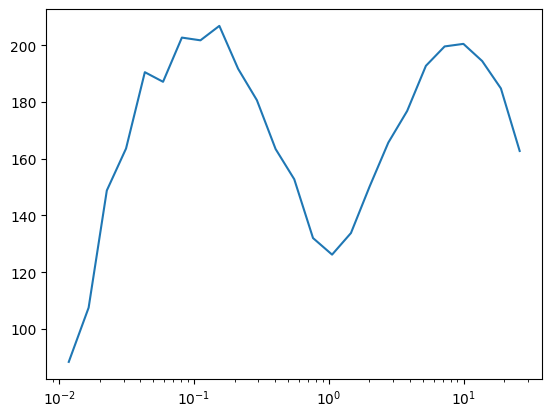

In [ ]:
import matplotlib.pyplot as plt
rp, wp = HOD_model.get_wp(cat, 'LRG2')
plt.plot(rp, rp*wp)
plt.xscale('log')

In [ ]:

HOD_model.args['use_assembly_bias'] = True
HOD_model.args['use_particles'] = True
cat1 = make_mock_cat(HOD_model, tracers=['LRG','LRG2', 'LRG3'], verbose=True, fix_seed=42)
cat1


Create mock catalog for ['LRG', 'LRG2', 'LRG3']
Run HOD for LRG
Set density to 0.0007 gal/Mpc/h
Initialisation in 0.04 sec
Ncent, Nsat computed in 0.05 sec
Central catalog in 0.51 sec
HOD computed for LRG in 0.60 sec
Start satellite assignement
Using particles
Using Abacus particles


/tmp/ipykernel_55256/1064807129.py:247: RuntimeWarning: divide by zero encountered in divide
  weight[weight > 0] = ( cc / cc_1 )[idx]                    # one value per element of `masses`


sat from part done 0.07595181465148926
0 satellites will be positioned using NFW
Satellite assignement done 0.18391966819763184
Make final catalog
LRG mock catalogue done 0.0023956298828125
Done overall time  LRG 0.8494813442230225
Run HOD for LRG2
No density set
Initialisation in 0.02 sec
Ncent, Nsat computed in 0.08 sec
Central catalog in 0.47 sec
HOD computed for LRG2 in 0.57 sec
Start satellite assignement
Using particles
Using Abacus particles
sat from part done 0.021697044372558594
0 satellites will be positioned using NFW
Satellite assignement done 0.08003425598144531
Make final catalog
LRG2 mock catalogue done 0.0011167526245117188
Done overall time  LRG2 1.502180814743042
Run HOD for LRG3
No density set
Initialisation in 0.02 sec
Ncent, Nsat computed in 0.09 sec
Central catalog in 0.47 sec
HOD computed for LRG3 in 0.58 sec
Start satellite assignement
Using particles
Using Abacus particles
sat from part done 0.01929330825805664
0 satellites will be positioned using NFW
Satellit

Catalog(csize=163099, size=163099, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id', 'env', 'shear', 'ab_env', 'ab_c', 'Central', 'TRACER'])

In [ ]:
(cat1['TRACER'] == 'LRG2').sum(), (cat['TRACER'] == 'LRG2').sum() 

(array(48174), array(74850))

In [ ]:
(np.unique(cat['halo_id'][cat['Central'] == 1], return_counts=True)[1] >1).sum(), (np.unique(cat1['halo_id'][cat1['Central'] == 1], return_counts=True)[1] >1).sum()

(35927, 0)

#Compute wp for ELG...
[009331.70]  07-24 16:25 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[009331.70]  07-24 16:25 TwoPointCorrelationFunction  INFO     Running auto-correlation.
[009331.70]  07-24 16:25 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[009331.86]  07-24 16:25 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[009331.86]  07-24 16:25 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.16 s.
Done in 0.160 s
#Compute wp for ELG...
[009331.87]  07-24 16:25 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[009331.87]  07-24 16:25 TwoPointCorrelationFunction  INFO     Running auto-correlation.
[009331.87]  07-24 16:25 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[009332.04]  07-24 16:25 TwoPointCorrelationFunction  INFO  

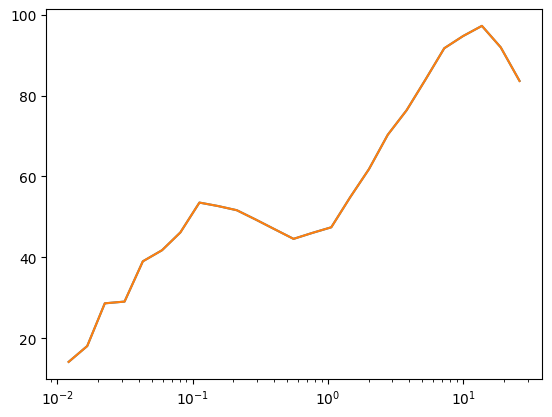

In [ ]:
import matplotlib.pyplot as plt

rp, wp = HOD_model.get_wp(cat1, 'ELG')
plt.plot(rp, rp*wp)
rp, wp = HOD_model.get_wp(cat, 'ELG')
plt.plot(rp, rp*wp)
plt.xscale('log')


#Compute wp for ['LRG3' 'LRG3']...
[009914.92]  07-24 16:35 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[009914.92]  07-24 16:35 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[009914.92]  07-24 16:35 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[009915.10]  07-24 16:35 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[009915.10]  07-24 16:35 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.19 s.
#Done in 0.194 s
#Compute wp for ['LRG3' 'LRG']...
[009915.12]  07-24 16:35 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[009915.12]  07-24 16:35 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[009915.12]  07-24 16:35 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[009915.31]  07-24 16:35 TwoPointC

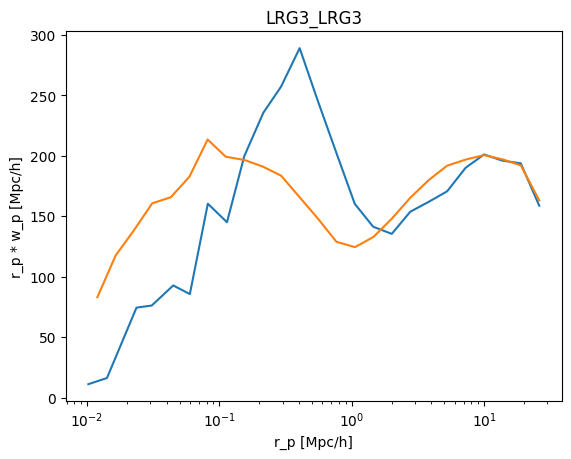

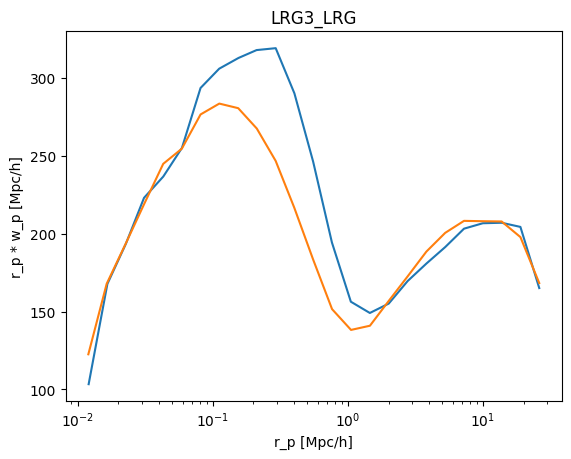

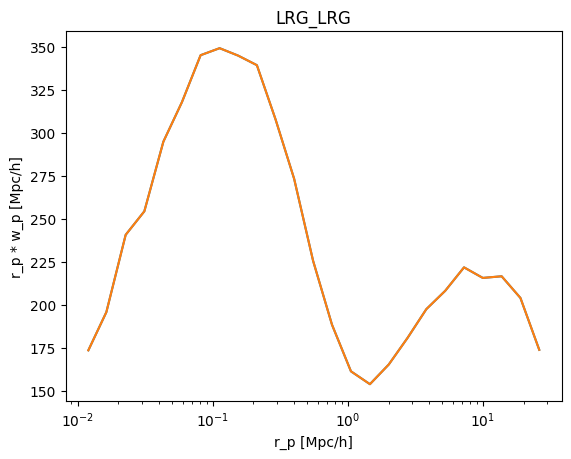

In [ ]:

res = HOD_model.get_crosswp(cat1, tracers=['LRG3','LRG'])


res1 = HOD_model.get_crosswp(cat, tracers=['LRG3','LRG'])

for tr in res1:
    rp, wp = res[tr]
    rp1, wp1 = res1[tr]
    plt.plot(rp, rp*wp)
    plt.plot(rp1, rp1*wp1)

    plt.xscale('log')
    plt.title(tr)
    plt.xlabel('r_p [Mpc/h]')
    plt.ylabel('r_p * w_p [Mpc/h]')
    plt.show()


In [ ]:
for i in res:
    print(i)

LRG_LRG
LRG_ELG
ELG_ELG


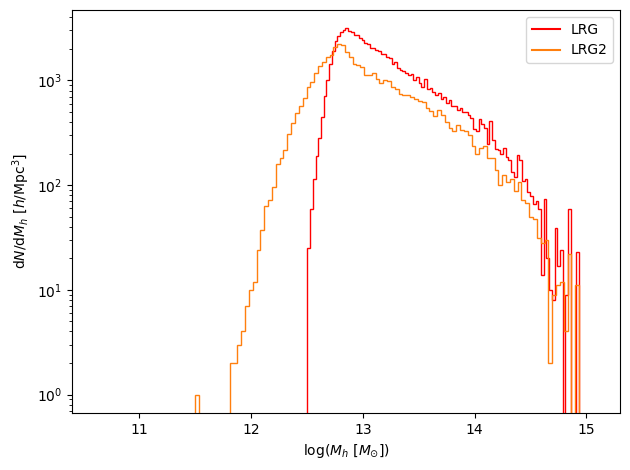

In [ ]:
HOD_model.plot_HMF(cat1, tracer=['LRG', 'LRG2'])

In [ ]:
import numba

@numba.njit(fastmath=True)
def test_numba(x: np.ndarray, list_func:list[callable], pcen:list[np.ndarray], psat:list[np.ndarray]):


    for func, p_cen, p_sat in zip(list_func, pcen, psat):
        for i in range(x.size):
            result = [func(x[i], p_cen)]
    
    return result

In [ ]:
from numba import types, typed

@numba.jit(fastmath=True)
def dummy_func(x, p):
    return x + p[0]

import math
@numba.njit(fastmath=True)
def mHMQ(log10_Mh, Ac, Mc, sig_M, gamma):

    """
    Computes a simplified version of the HMQ model without normalization and quenching terms 
    based on arxiv:2306.06319.

    Parameters:
    -----------
    - log10_Mh: float
        Logarithm (base 10) of halo mass.
    - Ac: float
        Normalization amplitude.
    - Mc: float
        Mean halo mass (log10).
    - sig_M: float
        Width of central galaxy mass distribution.
    - gamma: float
        Shape parameter controlling the asymetry.

    Returns:
    --------
    - float
        Expected number of galaxies in a halo of mass log10_Mh.

    """

    phi_x = 1 / (np.sqrt(2 * np.pi) * sig_M) * np.exp(
            - (log10_Mh - Mc)**2 / (2 * sig_M**2))
    PHI_gamma_x = 0.5 * (1 + math.erf(gamma * (log10_Mh - Mc) / (sig_M * np.sqrt(2))))
    return Ac * 2 * phi_x * PHI_gamma_x


# @hod_model(['Ac', 'log_Mcent', 'sigma_M', 'gamma'])
@numba.njit(fastmath=True)
def _mHMQ(log10_Mh, p_cen):
    """
    Wrapper for mHMQ using parameter array.

    Parameters:
    -----------
    - log10_Mh: float
    - p_cen: array-like
        Parameters [Ac, Mc, sig_M, gamma]

    Returns:
    --------
    - float
        Expected number of galaxies in a halo of mass log10_Mh.

    """

    Ac, Mc, sig_M, gamma = p_cen
    return mHMQ(log10_Mh, Ac, Mc, sig_M, gamma)



signature = types.float64(types.float64, types.float64[:])
list_func = [dummy_func, _mHMQ]

funcs = typed.List.empty_list(types.FunctionType(signature))
# funcs.append(dummy_func)
funcs.append(_mHMQ)

@numba.njit(fastmath=True)
def test_numba(x: np.ndarray, list_func:list[callable], pcen:list[np.ndarray], psat:list[np.ndarray]):

    res = np.empty_like(x, dtype=np.float64)

    for func, p_cen, p_sat in zip(list_func, pcen, psat):
        # for j in range(x.size):
            # res[j] = func(x[j], p_cen)
        pass
    
    
    return func(x[0], p_cen)


In [ ]:
test_numba(np.array([1,2,3]), funcs, [np.array([1]).astype(np.float64), np.array([2]).astype(np.float64)], [np.array([3]).astype(np.float64), np.array([4]).astype(np.float64)])

Exception ignored in: '<numba.core.cpu.CPUContext object at 0x712ce6b76d70>'
Traceback (most recent call last):
  File "/tmp/ipykernel_35908/3906458257.py", line 60, in _mHMQ
ValueError: 


0.0

In [ ]:
%load_ext line_profiler

import HOD_models
from numba import njit, numba, types, typed
import time 
from mpytools import Catalog
from utils import cmp_sample, getPointsOnSphere_jit, compute_fast_NFW, sample_satellites_from_particles, halo_to_particle_indices, compute_ngal
import numpy as np
 
@njit(fastmath=True)
def null_sat(log10_Mh, p):
    """
    A placeholder function for satellite HOD that always returns 0.

    Parameters:
    -----------
    - log10_Mh: float
        Logarithm (base 10) of halo mass.
    - p: array-like
        Parameters (not used in this function).

    Returns:
    --------
    - float
        Always returns 0, indicating no satellites.

    """
    return 0.0

def ngal(self, tracer, return_mass=False, verbose=False):
        """
        Return the number of galaxy and the satelitte fraction 
        
        Parameters
        ----------
            tracer: str
                Name of the galaxy tracer in self.tracers 
            return_mass (bool, optional): Defaults to False.
            verbose (bool, optional): Defaults to False.

        Returns
        -------
        ngal: float
            Total number of galaxies expected
        
        fsat: float
            Expected fraction of satellite galaxy (n_sat/ngal)
        
        mean_hmass: float, optional
            Mean halo mass of the galaxies in log10(Msun/h) (only returned if return_mass is True)
        
        """
        start = time.time()
        hod_list_param_cen, hod_list_param_sat = __init_hod_param(self, tracer)[:2]
        ngal, fsat, mean_hmass = compute_ngal(self.hcat['log10_Mh'], self._fun_cHOD[tracer], self._fun_sHOD[tracer], self.nthreads, 
                                hod_list_param_cen[0], hod_list_param_sat[0], self.args[tracer]['conformity_bias'], self.args[tracer]['link_sat_to_central'])
        if verbose:
            print(time.time()-start)
        if return_mass:
            return ngal, fsat, np.log10(mean_hmass)   
        else:
            return ngal, fsat

def __init_hod_param(self, tracers):
    """
    Initialize the HOD parameters for a list of tracers.

    Parameters
    ----------
    tracers : list of str
        Keys identifying the tracers. Each must be in self.tracers.

    Returns
    -------
    tuple of lists
        - list of np.float64 arrays of central parameters, one per tracer
        - list of np.array (or None) of satellite parameters, one per tracer
        - list of np.array (or None) of assembly bias parameters, one per tracer
    """
    if isinstance(tracers, str):
        tracers = [tracers]
    hod_list_param_cen, hod_list_param_sat, hod_param_ab = [], [], []

    signature = types.float64(types.float64, types.float64[:])
    list_cfuncs = typed.List.empty_list(types.FunctionType(signature))
    list_sfuncs = typed.List.empty_list(types.FunctionType(signature))
    sat_list = []
    for tracer in tracers:
        args_tr = self.args[tracer]

        self._fun_cHOD[tracer] = getattr(HOD_models, '_'+self.args[tracer]['HOD_model'])
        self._fun_sHOD[tracer] = null_sat

        cen = np.array(
            [args_tr[name] for name in self._cen_param_names(args_tr['HOD_model'])],
            dtype='float64')

        sat = np.array([0.], dtype='float64')
        sat_list.append(False)
        if args_tr['satellites']:
            self._fun_sHOD[tracer] = getattr(HOD_models, '_'+self.args[tracer]['sat_HOD_model'])
            sat = np.array(
                [args_tr[name] for name in self._sat_param_names(args_tr['sat_HOD_model'])],
                dtype='float64')
            sat_list[-1] = True

        ab = np.array([[0., 0]], dtype='float64').T
        if self.args['use_assembly_bias']:
            if  self.args[tracer].get('assembly_bias'): #check if assembly_bias is defined for the tracer
                ab = np.array(list(args_tr['assembly_bias'].values()), dtype='float64').T

        hod_list_param_cen.append(cen)
        hod_list_param_sat.append(sat)
        hod_param_ab.append(ab)

    
    # funcs.append(dummy_func)
        list_cfuncs.append(self._fun_cHOD[tracer])
        list_sfuncs.append(self._fun_sHOD[tracer])
        

    return hod_list_param_cen, hod_list_param_sat, hod_param_ab, list_cfuncs, list_sfuncs, sat_list

def get_ds_fac(self, tracers, verbose=False):
    """
    Calculate the density scaling factor for a list of tracers.

    Parameters
    ----------
    tracers : list of str
        Keys identifying the tracers. Each must be in self.tracers.
    verbose : bool, optional
        If True, prints information about the density and scaling factor for
        each tracer. Default is False.

    Returns
    -------
    list of float
        The density scaling factor for each tracer, in the order given.
        A tracer with no density set contributes 1.
    """
    ds_fac = []
    if isinstance(tracers, str):
        tracers = [tracers]
    for tracer in tracers:
        density = self.args[tracer]['density']
        if isinstance(density, float):
            if verbose:
                print('{}: set density to {} gal/Mpc/h'.format(tracer, density))
            ds_fac.append(density * self.boxsize**3 / ngal(self, tracer)[0])
        else:
            if verbose:
                print('{}: no density set'.format(tracer))
            ds_fac.append(1)
    return ds_fac

def make_mock_cat(self, tracers=None, fix_seed=None, verbose=True):
    """
    Generate HOD mock catalogs.

    This method creates mock galaxy catalogs based on the Halo Occupation Distribution (HOD) model for each 
    specified tracer. It computes the central and satellite galaxies, assigns them to halos, and optionally 
    includes assembly bias effects, conformity bias, and uses particle-level data for satellite galaxy 
    positions. It handles multiple tracers and provides options for reproducibility and verbose output.

    Parameters
    ----------
    tracers : list or str, optional
        Name(s) of the galaxy tracers (e.g., 'LRG', 'ELG') to include in the mock catalog. If None, all 
        tracers defined in `self.tracers` are considered. Defaults to None.
    fix_seed : int, optional
        Fix the seed for reproducibility. This is useful for ensuring consistent results when using a fixed 
        number of threads (`nthreads`). Defaults to None.
    verbose : bool, optional
        If True, the function prints progress messages during execution. Defaults to True.

    Returns
    -------
    final_cat : dict
        A dictionary containing mock catalogs for each tracer specified. Each catalog is represented by a `Catalog`
        object, which contains the generated galaxy data (centrals and satellites) for the corresponding tracer.

    Notes
    -----
    - The method relies on HOD models defined for each tracer in `self.args[tracer]['HOD_model']` and `self.args[tracer]['sat_HOD_model']`.
    - If `self.args['assembly_bias']` is enabled, assembly bias columns will be computed and included in the mock catalog.
    - The `fix_seed` parameter ensures that the mock catalogs are generated in a reproducible manner, but it requires consistent 
    thread configurations (`self.nthreads`).
    - When `tracers` includes both 'ELG' and 'LRG', the method handles the case where both tracers share the same halo by placing
    one LRG at the center and positioning other galaxies (like ELGs) based on the NFW profile.

    Example
    -------
    To generate mock catalogs for both 'LRG' and 'ELG' tracers with fixed seed for reproducibility:

    final_cat = mock_catalog.make_mock_cat(tracers=['LRG', 'ELG'], fix_seed=42)
    """

    rng = np.random.RandomState(seed=fix_seed)
    start = time.time()
    
    if tracers is None: 
        tracers = self._tracers()
    else:
        tracers = tracers if isinstance(tracers, list) else [tracers]
        for tr in tracers:
            if tr not in self._tracers():
                raise ValueError(f'{tr} not in defined tracers {self._tracers()}')
    # Fail early with a clear message if any required HOD parameter is missing.
    self.check_HOD_params(tracers)
    if verbose:
        print('Create mock catalog for {}'.format(tracers), flush=True)         
    
    if self.args['use_assembly_bias']:
        self._compute_assembly_bias_columns()

    final_cat = {}

    hod_list_param_cen, hod_list_param_sat, hod_list_ab_param, list_cfuncs, list_sfuncs, sat_list = __init_hod_param(self, tracers)

    ds = get_ds_fac(self, tracers, verbose=verbose)
    list_nu = np.array([self.args[tracer]['nu'] for tracer in tracers]).astype(np.float64)
    list_conf = np.array([self.args[tracer]['conformity_bias'] for tracer in tracers], dtype=np.bool_)
    list_link_sat_to_central = np.array([self.args[tracer]['link_sat_to_central'] for tracer in tracers], dtype=np.bool_)
    # ab_arr = [np.zeros_like(self.hcat['log10_Mh'])]
    N = max(a.shape[1] for a in hod_list_ab_param)
    Nhalo = self.hcat['log10_Mh'].size
    ab_arr_3d = np.zeros((len(tracers), Nhalo, N))
    for i, tracer in enumerate(tracers):
        if (hod_list_param_cen[i][0]*ds[i] > 1):
            import warnings
            warnings.warn('Ac={} is > 1, the density is not fixed to {}'.format(hod_list_param_cen[i][0]*ds[i], self.args[tracer]["density"]))
        else : 
            hod_list_param_cen[i][0] *= ds[i]
            hod_list_param_sat[i][0] *= 1 if self.args[tracer]['link_sat_to_central'] else ds[i]

        if self.args['use_assembly_bias']:
            if not self.args[tracer].get('assembly_bias'): #check if assembly_bias is defined for the tracer
                continue                             
            if self.args['use_assembly_bias']:
                cols_ab = ['ab_'+c for c in self.args[tracer]['assembly_bias'].keys()]
                if np.all([c in self.hcat.columns() for c in cols_ab]):
                    block = np.vstack([self.hcat[c] for c in cols_ab]).T   # (Nhalo, ncol)
                    ab_arr_3d[i, :, :block.shape[1]] = block


    ab_arr_3d = np.ascontiguousarray(ab_arr_3d)

    # N = max(a.shape[1] for a in hod_list_ab_param)
    # hod_list_ab_param = [np.pad(a, ((0, 0), (0, N - a.shape[1]))) for a in hod_list_ab_param]


    # tl_hod_list_ab_param = typed.List.empty_list(types.float64[:, ::1])   # note ::1 = C-contiguous
    # for a in hod_list_ab_param:
    #     tl_hod_list_ab_param.append(np.ascontiguousarray(a))
    
    p_ab_arr = np.zeros((len(tracers), 2, N))
    for i, a in enumerate(hod_list_ab_param):
        p_ab_arr[i, :, :a.shape[1]] = a
    p_ab_arr = np.ascontiguousarray(p_ab_arr)
    
    if fix_seed is not None:
        seed = rng.randint(0, 4294967295, self.nthreads)
    else:
        seed = None
    
    if verbose:
        print("Initialisation in {:.2f} sec".format(time.time()-start), flush=True)
        st = time.time()

    start = time.time()
    cond_cent, proba_sat = compute_N_v2(self.hcat['log10_Mh'], list_cfuncs, list_sfuncs, hod_list_param_cen, 
                                            hod_list_param_sat, list_nu, p_ab_arr, ab_arr_3d, list_conf,
                                            list_link_sat_to_central, sat_list, self.nthreads, seed)
    print("compute_N_v2 done in {:.2f} sec".format(time.time()-start), flush=True)

    return cond_cent, proba_sat


@njit(parallel=True, fastmath=True)
def compute_N_v2(log10_Mh: np.ndarray, list_fun_cHOD: list[callable], list_fun_sHOD: list[callable], list_p_cen: list[np.ndarray], list_p_sat: list[np.ndarray], list_nu:list[float], list_p_ab:list[np.ndarray], list_ab_arr:list[np.ndarray], list_conformity:list[bool], list_link_sat_to_central:list[bool], sat_list:list[bool], Nthread=32, seed:int=None):
    """
    Compute the number of central and satellite galaxies in a halo using a HOD (Halo Occupation Distribution) model.

    Parameters:
        log10_Mh : ndarray
            Logarithmic mass of halos.
        list_fun_cHOD : list[callable]
            List of functions to compute central occupation based on halo mass.
        list_fun_sHOD : list[callable]
            List of functions to compute satellite occupation based on halo mass.
        list_p_cen : list[ndarray]
            Parameters for the central HOD function.
        list_p_sat : list[ndarray]
            Parameters for the satellite HOD function.
        nu : list[float], optional
            List of nuisance parameters. Default is [1.0].
        list_p_ab : list[ndarray] or None, optional
            List of assembly bias parameters (central and satellite). Default is None.
        Nthread : int, optional
            Number of threads to use in parallel computation. Default is 32.
        list_ab_arr : list[ndarray] or None, optional
            List of assembly bias arrays per halo. Default is [None].
        list_conformity : list[bool], optional
            Whether satellite number is correlated with central galaxy presence. Default is False.
        seed : ndarray or None, optional
            Seed array for RNG per thread. Default is None.

    Returns:
        Ncent : ndarray
            Expected number of central galaxies.
        N_sat : ndarray
            Expected number of satellite galaxies.
        cond_cent : ndarray
            Boolean array indicating presence of a central galaxy.
        proba_sat : ndarray
            Sampled number of satellites per halo.
    """


    numba.set_num_threads(Nthread)
    # starting index of each thread
    hstart = np.rint(np.linspace(0, len(log10_Mh), Nthread + 1))
    cond_cent = np.zeros((log10_Mh.size, len(list_fun_cHOD)), dtype=np.bool_)
    proba_sat = np.zeros((log10_Mh.size, len(list_fun_cHOD)), dtype=np.int64)

    for tid in numba.prange(Nthread):
        if seed is not None:
            np.random.seed(seed[tid])
        for i in range(int(hstart[tid]), int(hstart[tid + 1])):
            for (j, fun_cHOD), fun_sHOD, p_cen, p_sat, nu, (p_abc, p_abs), ab_arr, conformity, link_sat_to_central, sat in zip(enumerate(list_fun_cHOD), list_fun_sHOD, list_p_cen, list_p_sat, list_nu, list_p_ab, list_ab_arr, list_conformity, list_link_sat_to_central, sat_list):
                Ncent = fun_cHOD(log10_Mh[i], p_cen)
                if np.sum(p_abc) != 0:
                    Ncent *= 1 + np.sum(p_abc * ab_arr[i])*(1-Ncent)
                cond_cent[i, j] = Ncent - np.random.uniform(0, 1) > 0
                if sat:
                    N_sat = fun_sHOD(log10_Mh[i], p_sat)
                    if link_sat_to_central:
                        N_sat *= Ncent
                    if np.sum(p_abs) != 0:
                        N_sat *= (1 + np.sum(p_abs * ab_arr[i]))
                    if N_sat <=0:
                        proba_sat[i, j] = 0
                    elif conformity:
                        proba_sat[i, j] = np.random.poisson(N_sat*cond_cent[i, j])
                    else :
                        if nu == 1:
                            proba_sat[i, j] = np.random.poisson(N_sat)
                        else:
                            proba_sat[i, j] = cmp_sample(N_sat, nu)

    return cond_cent, proba_sat



    # if verbose:
    #     print('Ncent, Nsat computed in {:.2f} sec'.format(time.time()-st), flush=True)
    #     st = time.time()
        
    #     cent_cat = self.hcat[cond_cent]
    #     cent_cat['Central'] = np.ones(cent_cat['x'].size,dtype='int')

    #     if verbose:
    #         print('Central catalog in {:.2f} sec'.format(time.time()-st), flush=True)
    #         print("HOD computed for {} in {:.2f} sec".format(tracer, time.time()-start), flush=True)
        
    #     if (not self.args[tracer]['satellites']) | (Nb_sat == 0):
    #         Nb_sat=0
    #         final_cat[tracer] = cent_cat
    #         final_cat[tracer]['TRACER'] = [tracer]*final_cat[tracer].size





            
    #     else:
    #         start_sat = time.time()
    #         if verbose:
    #             print("Start satellite assignement", flush=True)
    #         mask_sat = proba_sat > 0
    #         list_nsat = proba_sat[mask_sat]
    #         # sat_cat = Catalog.from_array(np.repeat(self.hcat[mask_sat].to_array(), list_nsat))
    #         sat_cat = Catalog()
    #         sat_cat.data = {col: np.repeat(self.hcat[mask_sat][col], list_nsat) for col in self.hcat.columns()}
            
    #         if self.args['use_particles'] & (self.part_subsamples is not None):
    #             if verbose: print('Using particles', flush=True)
    #             if self.base_catalog._is_sim_abacus:
    #                     print('Using Abacus particles', flush=True)
    #                     start = time.time()
    #                 if fix_seed is not None:
    #                     seed = rng.randint(0, 4294967295, self.nthreads)
    #                 else:
    #                     seed = None
    #                 mask_nfw = compute_sat_from_abacus_part(self.part_subsamples['pos'].T[0],self.part_subsamples['pos'].T[1],self.part_subsamples['pos'].T[2],
    #                     self.part_subsamples['vel'].T[0], self.part_subsamples['vel'].T[1],self.part_subsamples['vel'].T[2],
    #                     sat_cat['x'], sat_cat['y'], sat_cat['z'], sat_cat['vx'], sat_cat['vy'], sat_cat['vz'],
    #                     self.hcat['npoutA'][mask_sat], self.hcat['npstartA'][mask_sat], list_nsat, np.insert(np.cumsum(list_nsat), 0, 0), self.nthreads, seed=seed)
    #                 if verbose: 
    #                     print('sat from part done', time.time() - start, flush=True)
    #                     print(f'{mask_nfw.sum()} satellites will be positioned using NFW', flush=True)

    #             else:
    #                 if fix_seed is not None:
    #                     seed = rng.randint(0, 4294967295, sat_cat.size)
    #                 else:
    #                     seed = None
    #                 start = time.time()
    #                 start_part = time.time()
    #                 uniq_sat_id = np.unique(sat_cat['halo_id'])
    #                 if not hasattr(self, '_order_part_index'):
    #                     self._order_part_index = np.argsort(self.part_subsamples['halo_id'])
    #                 flat, offsets = halo_to_particle_indices(self.part_subsamples['halo_id'][self._order_part_index], self._order_part_index, uniq_sat_id, self.nthreads)
    #                 # result = [flat[offsets[i]:offsets[i+1]] for i in range(len(uniq_sat_id))]
    #                 start = time.time()
    #                 sat_cat = sat_cat[sat_cat['halo_id'].argsort()]
    #                 start = time.time()
                    
    #                 mask_nfw = sample_satellites_from_particles(sat_cat['x'], sat_cat['y'], sat_cat['z'], sat_cat['vx'], sat_cat['vy'], sat_cat['vz'],
    #                                                     self.part_subsamples['x'], self.part_subsamples['y'], self.part_subsamples['z'],
    #                                                     self.part_subsamples['vx'], self.part_subsamples['vy'], self.part_subsamples['vz'], flat, offsets,
    #                                                     list_nsat, self.nthreads, seed=seed)
    #                 if verbose: 
    #                     print('sample_satellites_from_particles done', time.time() - start, flush=True)
    #                     print('sat from part done', time.time() - start_part, flush=True)
    #                     print(f'{mask_nfw.sum()} satellites will be positioned using NFW', flush=True)
            
    #         else:
    #             if self.args['use_particles']:
    #                 import warnings
    #                 warnings.warn('use_particles is set to True but no particle subsample found, continue with NFW profile for satellites')
    #             if self.part_subsamples is not None:
    #                 import warnings
    #                 warnings.warn('Particle subsample loaded but use_particles is set to False, continue with NFW profile for satellites. To use particles, set use_particles to True.')
    #             mask_nfw = np.ones(Nb_sat, dtype=bool)
                
            
    #         if mask_nfw.sum() > 0:
    #             start = time.time()
    #             if fix_seed is not None:
    #                 seed1 = rng.randint(0, 4294967295, self.nthreads)
    #             else:
    #                 seed1 = None
    #             rd_pos = getPointsOnSphere_jit(Nb_sat, np.minimum(Nb_sat, self.nthreads), seed1)
    #             if self.args[tracer]['vel_sat'] == 'NFW':
    #                 seed2 = rng.randint(0, 4294967295, self.nthreads)
    #                 rd_v = getPointsOnSphere_jit(Nb_sat, np.minimum(Nb_sat, self.nthreads), seed2)
    #                 ut = np.cross(rd_pos,rd_v, axis=1) 
    #                 rd_vel = (ut.T / np.linalg.norm(ut, axis=1).flatten()).T
    #             else:
    #                 rd_vel = np.ones_like(rd_pos)
                
    #             vrms_h = sat_cat['Vrms'][mask_nfw] if 'Vrms' in sat_cat.columns() else np.zeros_like(sat_cat['vx'][mask_nfw])

    #             sat_cat['x'][mask_nfw], sat_cat['y'][mask_nfw], sat_cat['z'][mask_nfw], \
    #             sat_cat['vx'][mask_nfw], sat_cat['vy'][mask_nfw], sat_cat['vz'][mask_nfw] = compute_fast_NFW(sat_cat['x'][mask_nfw], sat_cat['y'][mask_nfw], sat_cat['z'][mask_nfw],
    #             sat_cat['vx'][mask_nfw], sat_cat['vy'][mask_nfw], sat_cat['vz'][mask_nfw],
    #             sat_cat['c'][mask_nfw], sat_cat['Mh'][mask_nfw], sat_cat['Rh'][mask_nfw], 
    #             rd_pos, rd_vel, exp_frac=self.args[tracer]['exp_frac'], 
    #             exp_scale=self.args[tracer]['exp_scale'], nfw_rescale=self.args[tracer]['nfw_rescale'],
    #             vrms_h=vrms_h, f_sigv=self.args[tracer]['f_sigv'], v_infall=self.args[tracer]['v_infall'], 
    #             vel_sat=self.args[tracer]['vel_sat'], Nthread=self.nthreads, seed=seed)
    #             if verbose:
    #                 print("NFW Computed", time.time() - start, flush=True)
    #         sat_cat['Central'] = sat_cat.zeros()

    #         if verbose:
    #             print("Satellite assignement done", time.time() - start_sat, flush=True)

    #         if verbose:
    #             print("Make final catalog", flush=True)
    #             start = time.time()
    #         final_cat[tracer] = Catalog.concatenate((cent_cat,sat_cat))
    #         # final_cat[tracer]['TRACER'] = [tracer]*final_cat[tracer].size
    #         final_cat[tracer]['TRACER'] = np.full(final_cat[tracer].size, tracer)
    #         if verbose:
    #             print('{} mock catalogue done'.format(tracer), time.time()-start, flush=True)
                
            
    #     # mask_id &= (mask_cent | mask_sat)
    #     # count_gal[tracer] = np.int64(proba_sat + cond_cent)

    #     if verbose:
    #         print("Done overall time ", tracer, time.time() - start_all, flush=True)

    # # When LRG and ELG are in the same halo, put 1 LRG at the center and all other galaxies are position following NFW profile
    # # if ((tracers == ['ELG', 'LRG']) | (tracers == ['LRG', 'ELG'])) & (mask_id.sum() >0):
    # #     mask_elg = np.in1d(final_cat['ELG']['halo_id'], final_cat['LRG']['halo_id'])
    # #     mask_lrg = np.in1d(final_cat['LRG']['halo_id'], final_cat['ELG']['halo_id'])
        
    # #     cen_LRG = self.hcat[mask_id]
    # #     cen_LRG['Central'] = cen_LRG.ones()

    # #     if ((count_gal['LRG'] > 1) & mask_id).sum() > 0:
    # #         sat_LRG = Catalog.from_array(np.repeat(self.hcat[(count_gal['LRG'] > 1) & mask_id].to_array(), count_gal['LRG'][(count_gal['LRG'] > 1) & mask_id]-1))
    # #         sat_LRG = self.init_elg_sat_for_lrg('LRG', sat_LRG, fix_seed=fix_seed)
    # #         final_cat['LRG'][mask_lrg] = Catalog.concatenate(cen_LRG, sat_LRG)
    # #     else:
    # #         final_cat['LRG'][mask_lrg] = cen_LRG
        
    # #     sat_ELG = Catalog.from_array(np.repeat(self.hcat[mask_id].to_array(), count_gal['ELG'][mask_id]))
    # #     sat_ELG = self.init_elg_sat_for_lrg('ELG', sat_ELG, fix_seed=fix_seed)
    # #     final_cat['ELG'][mask_elg] = sat_ELG
    
    # if verbose:
    #     st = time.time()
    #     final_cat = Catalog.concatenate(list(final_cat.values())) 
    #     Nb_sat = np.count_nonzero(final_cat['Central'])
    #     # print("{} central galaxies, {} satellites, fraction of satellite {:.2f} ".format(final_cat.size-Nb_sat,Nb_sat, Nb_sat/final_cat.size), flush=True)
    #     print('Total time to create the mock catalog: {:.2f} seconds'.format((time.time() - start_all)), flush=True)
    #     return final_cat
    # return Catalog.concatenate(list(final_cat.values())) 





The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [ ]:

HOD_model.args['use_assembly_bias'] = True
HOD_model.args['use_particles'] = True
cat = HOD_model.make_mock_cat('LRG')
cat


Create mock catalog for ['LRG']
Run HOD for LRG
Set density to 0.0007 gal/Mpc/h
Initialisation in 0.09 sec
Ncent, Nsat computed in 0.13 sec
Central catalog in 0.03 sec
HOD computed for LRG in 0.25 sec
Start satellite assignement
Using particles
Using Abacus particles
sat from part done 0.06554460525512695
0 satellites will be positioned using NFW
Satellite assignement done 0.1197655200958252
Make final catalog
LRG mock catalogue done 0.0017447471618652344
Done overall time  LRG 0.37160801887512207
Total time to create the mock catalog: 0.37 seconds


Catalog(csize=87650, size=87650, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id', 'env', 'shear', 'ab_env', 'ab_c', 'Central', 'TRACER'])

In [ ]:
# HOD_model.args['LRG'].pop('assembly_bias', None)  # Remove assembly_bias for LRG
cond_cen, proba_sat = make_mock_cat(HOD_model)

Create mock catalog for ['LRG', 'ELG']
LRG: set density to 0.0007 gal/Mpc/h
ELG: set density to 0.001 gal/Mpc/h
Initialisation in 0.20 sec
compute_N_v2 done in 1.00 sec


In [ ]:
cc

array([554499, 476131, 407620, 348326, 361843, 361286, 301533, 294329,
       242072, 229581, 213116, 179686, 183324, 152447, 151140, 136618,
       121478, 115533, 107124,  94116,  86681,  82138,  73770,  68535,
        60412,  57221,  51364,  47772,  43089,  39958,  36469,  33351,
        30600,  27928,  24950,  23090,  21282,  19417,  17697,  15882,
        14670,  13555,  11996,  10986,  10236,   9193,   8563,   7502,
         7007,   6235,   5498,   5084,   4558,   4122,   3697,   3376,
         3018,   2821,   2472,   2253,   1859,   1735,   1564,   1399,
         1263,   1118,   1027,    881,    741,    697,    583,    512,
          430,    411,    356,    316,    227,    197,    198,    152,
          138,     99,     76,     67,     63,     38,     46,     34,
           23,     17,     12,      9,      7,      2,      2,      3,
            1,      3,      1,      1])

In [ ]:
cc, bins = np.histogram(test.hcat['log10_Mh'], bins=100)
cc_1, bins = np.histogram(test.hcat['log10_Mh'][~cond_cen.T[0]], bins=bins)
idx = np.digitize(test.hcat['log10_Mh'][~cond_cen.T[0]], bins) - 1    # -1 because digitize is 1-based
idx = np.clip(idx, 0, len(cc) - 1)  # guard the rightmost edge

values =( cc / cc_1 )[idx]                    # one value per element of `masses`

/tmp/ipykernel_55256/2062465079.py:6: RuntimeWarning: divide by zero encountered in divide
  values =( cc / cc_1 )[idx]                    # one value per element of `masses`


In [ ]:
values.max()

6.0

In [ ]:
weight = np.ones_like(test.hcat['log10_Mh'])
weight[cond_cen.T[0]] = 0
ratio = cc / cc_1                      # shape (100,)
idx = np.digitize(test.hcat['log10_Mh'][~cond_cen.T[0]], bins) - 1    # -1 because digitize is 1-based
idx = np.clip(idx, 0, len(ratio) - 1)  # guard the rightmost edge

weight[weight > 0] = ratio[idx] 
# values = ratio[idx]                    # one value per element of `masses`

/tmp/ipykernel_55256/3863375974.py:3: RuntimeWarning: divide by zero encountered in divide
  ratio = cc / cc_1                      # shape (100,)


In [ ]:
weight[cond_cen.T[0]].sum()

array(0.0)

In [ ]:
len(values)

5980855

In [ ]:
cc_1, bins = np.histogram(self.hcat['log10_Mh'][~cond_cent], bins=bins)
idx = np.digitize(self.hcat['log10_Mh'][~cond_cent], bins) - 1    # -1 because digitize is 1-based
idx = np.clip(idx, 0, len(cc) - 1)  # guard the rightmost edge

weight[cond_cent] = 0
weight[weight > 0] = ( cc / cc_1 )[idx]                    # one value per element of `masses`

In [ ]:
ind_dup = np.where(mm)[0]
logM,counts = np.unique(test.hcat['log10_Mh'][ind_dup], return_counts=True)

In [ ]:
new_indices = []
for ii, count in zip(logM, counts):
    mask_hcat = (test.hcat['log10_Mh'] == ii) & ~cond_cen.T[1]
    index_avail = np.where(mask_hcat)[0]
    try:
        assert len(index_avail) >= count, f"Not enough available indices for logM={ii}. Needed {count}, but only {len(index_avail)} available."
    except AssertionError as e:
        print(e)
        continue  # Skip this iteration if there aren't enough available indices
    new_indices += np.random.choice(index_avail, size=count, replace=False).tolist()

In [ ]:
try:
    assert len(index_avail) >= 2000, f"Not enough available indices for logM={ii}. Needed {count}, but only {len(index_avail)} available."
    np.random.choice(index_avail, size=2000, replace=False)
except AssertionError as e:
    print(e)
    


Not enough available indices for logM=11.94214153289795. Needed 1, but only 1339 available.


In [ ]:
index_avail.size

1339

In [ ]:
cond_cen.T[1][ind_dup] = np.zeros(len(ind_dup), dtype=bool)
cond_cen.T[1][ind_dup]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

In [ ]:
cond_cen[ind_dup]

array([[ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False],
       [ True, False]])

In [ ]:
cond_cen.T[1][new_indices] = np.ones(len(new_indices), dtype=bool)

In [ ]:
cond_cen[new_indices]

array([[False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True]])

In [ ]:
new_indices

[4538748,
 1061898,
 4002703,
 2460734,
 94181,
 222194,
 542351,
 540781,
 503101,
 4055860,
 682115,
 4251544,
 4815845,
 3985931,
 496071,
 96315,
 4857309,
 4720007,
 4415337,
 3156142,
 3088609,
 4302437,
 879928,
 4920733,
 3159396,
 1277319,
 1454138,
 4196504,
 794599,
 1067613,
 5716596]

In [ ]:
# cond_cen.T[1][ind_dup] = np.zeros(len(ind_dup), dtype=bool)

In [ ]:
cond_cen.T[1][ind_dup]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [ ]:
mask_hcat.sum()

array(1641)

In [ ]:
cond_cen.T[0][1]

Catalog(csize=6046558, size=6046558, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'npstartA', 'npoutA', 'halo_id'])

In [ ]:
test.hcat

Catalog(csize=68135224, size=68135224, columns=['x', 'y', 'z', 'vx', 'vy', 'vz', 'Rs', 'Rh', 'c', 'Mh', 'log10_Mh', 'Vrms', 'halo_id'])

In [ ]:
HOD_model.args['ELG']['HOD_model'] = 'HMQ'

In [ ]:
from hod import HOD
HOD_model = HOD(base_catalog=test, param_file='/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/default_HOD_parameters.yaml', use_assembly_bias=False, use_particles=False)


Set number of threads to 19
Initialize Abacus c000 cosmology


array([[0],
       [0]])

In [ ]:
HOD_model.args['use_assembly_bias'] = True

hod_list_param_cen, hod_list_param_sat, hod_list_ab_param, list_cfuncs, list_sfuncs, sat = __init_hod_param(HOD_model, HOD_model._tracers())

In [ ]:
hod_list_ab_param = [array([[1., 1.],
        [0., 1.]]),
 array([[0.],
        [0.]])]

[array([[1., 1.],
        [0., 1.]]),
 array([[0.],
        [0.]])]

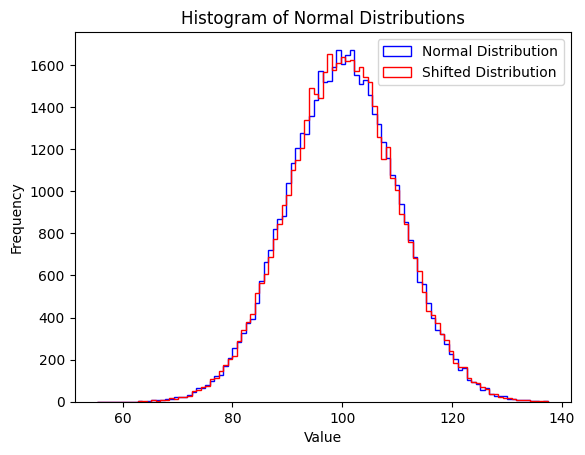

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a,b,_ = plt.hist(np.random.normal(100,10, size=50000), histtype='step', color='blue', label='Normal Distribution', bins=100)
plt.hist(100+ np.random.normal(loc=0, scale=10, size=50000), histtype='step', color='red', label='Shifted Distribution', bins=b)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Normal Distributions')
plt.legend()
plt.show()

In [ ]:
np.random.seed(42)
rd_pos = np.random.uniform(size=(10, 3))
p=2
i=1
a = rd_pos[i] * p
x_1 = 10
x2 = x_1 + a[0]
y1 = 5
y2 = y1 + a[1]
z1 = 3
z2 = z1 + a[2]
norm = np.sqrt(np.sum((rd_pos[i] * p)**2))
norm2 = np.sqrt((rd_pos[i, 0] * p)**2 + (rd_pos[i, 1] * p)**2 + (rd_pos[i, 2] * p)**2)
norm3 = np.sqrt((x_1-x2)**2 + (y1-y2)**2 + (z1-z2 )**2)



In [ ]:
norm, norm2, norm3

(1.2760377537385355, 1.2760377537385355, 1.2760377537385352)

array([51, 92, 14, 71, 60, 20, 82, 86, 74, 74, 87, 99, 23,  2, 21, 52,  1,
       87, 29, 37,  1, 63, 59, 20, 32, 75, 57, 21, 88, 48, 90, 58, 41, 91,
       59, 79, 14, 61, 61, 46, 61, 50, 54, 63,  2, 50,  6, 20, 72, 38])